# Wheat Futures Return Prediction - Regional Per-Region Approach For Large Price Changes

**Objective:** Predict 5-day forward returns on Milling Wheat N2 futures using per-region
agricultural data from CY-Bench, following the regional modelling methodology of
Paudel et al. (2022).

**Key Design Choices (following Paudel et al. 2022 & Thaker et al. 2024):**

1. **One model per region** - each NUTS-level region in FR, DE, PL gets its own regression
   model trained on that region's agricultural features + shared price features. This avoids
   aggregation errors that accumulate when predictors are averaged across heterogeneous
   regions (Paudel et al. 2022, Section 1).
2. **Region selection** - not all regions are informative. Adding too many regions can
   degrade performance (Thaker et al. 2024, Figure 5). We apply both forward and backward
   stepwise selection with the one-standard-error rule (MA429 Lecture 3) to select the
   most predictive subset.
3. **Production-weighted aggregation** - per-region predictions are aggregated to EU-level
   using crop-area/production weights (Paudel et al. 2022, Section 2.5.3; Cerrani &
   López Lozano, 2017).
4. **Four model families** - Ridge, Lasso, Gradient Boosted Trees, Random Forest
   (representing linear regularised, sparse linear, and two ensemble methods).
5. **Regression target** - continuous 5-day forward return (not classification).

**Period:** 2003–2023 | **Data:** Euronext Milling Wheat N2 + CY-Bench (FR, DE, PL)

In [48]:
import pandas as pd
import numpy as np
import os
import glob
import warnings
from datetime import timedelta
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("All imports successful.")

All imports successful.


---
## 1. Load and Prepare Futures Price Data

In [50]:
# ============================================================
# CONFIGURATION
# ============================================================
FUTURES_PATH = "CA1 Commodity Historical Data v2.xlsx"
CYBENCH_DATA_DIR = "cy-bench"

FORECAST_HORIZON = 5   # 5 trading days (1 week) forward return
AG_LAG_DAYS = 0        # No artificial lag: futures traders react in real time

# ============================================================
# Load futures data
# ============================================================
futures_raw = pd.read_excel(FUTURES_PATH, na_values=['#N/A N/A', '#N/A', 'N/A'])
futures_raw = futures_raw.drop(columns=[c for c in futures_raw.columns 
                                         if 'Unnamed' in str(c) or 'Setting' in str(c)],
                                errors='ignore')
print(f"Raw futures data shape: {futures_raw.shape}")
futures_raw.head()

Raw futures data shape: (6968, 16)


,Date,PX_LAST,PX_BID,OPEN_INT,PX_OPEN,PX_HIGH,PX_LOW,PX_VOLUME,PX_LAST_ADJ,PX_BID_ADJ,OPEN_INT_ADJ,PX_OPEN_ADJ,PX_HIGH_ADJ,PX_LOW_ADJ,PX_VOLUME_ADJ,ROLL
0,2026-03-02,201.25,201.00,NaN,203.75,204.25,200.50,85071.0,201.25,201.00,NaN,203.75,204.25,200.50,85071.0,1.001244
1,2026-02-27,197.50,193.75,9694.0,193.50,197.75,193.50,12930.0,201.50,197.67,9694.0,197.42,201.76,197.42,12930.0,0.999140
2,2026-02-26,193.25,192.00,15198.0,193.25,194.50,192.25,12908.0,197.16,195.89,15198.0,197.16,198.44,196.14,12908.0,0.986523
3,2026-02-25,193.00,192.50,19460.0,195.50,195.75,192.50,15145.0,196.91,196.40,19460.0,199.46,199.71,196.40,15145.0,0.982688
4,2026-02-24,195.25,195.00,25540.0,195.50,197.25,195.00,20632.0,199.20,198.95,25540.0,199.46,201.24,198.95,20632.0,0.981402


In [51]:
# Parse and clean futures data
futures = futures_raw.copy()
futures['Date'] = pd.to_datetime(futures['Date'], format='%m/%d/%Y')
futures = futures.sort_values('Date').reset_index(drop=True)

# Use adjusted columns
futures['Price'] = futures['PX_LAST_ADJ']
futures['Open'] = futures['PX_OPEN_ADJ']
futures['High'] = futures['PX_HIGH_ADJ']
futures['Low'] = futures['PX_LOW_ADJ']
futures['Volume'] = futures['PX_VOLUME_ADJ']

# Filter to 2003-2023
futures = futures[
    (futures['Date'] >= '2002-12-31') & (futures['Date'] <= '2023-12-31')
].copy()

futures = futures[['Date', 'Price', 'Open', 'High', 'Low', 'Volume']]
futures['Volume'] = futures['Volume'].ffill()
futures = futures.dropna(subset=['Price']).reset_index(drop=True)

print(f"Futures data: {futures.shape[0]} trading days from "
      f"{futures['Date'].min().date()} to {futures['Date'].max().date()}")
futures.head()

Futures data: 5389 trading days from 2002-12-31 to 2023-12-29


,Date,Price,Open,High,Low,Volume
0,2002-12-31,76.15,76.15,76.15,76.15,2.0
1,2003-01-02,76.15,76.15,76.15,76.15,38.0
2,2003-01-03,76.15,76.15,76.15,76.15,4.0
3,2003-01-06,76.15,76.15,76.15,76.15,5.0
4,2003-01-07,75.31,75.98,75.98,75.31,97.0


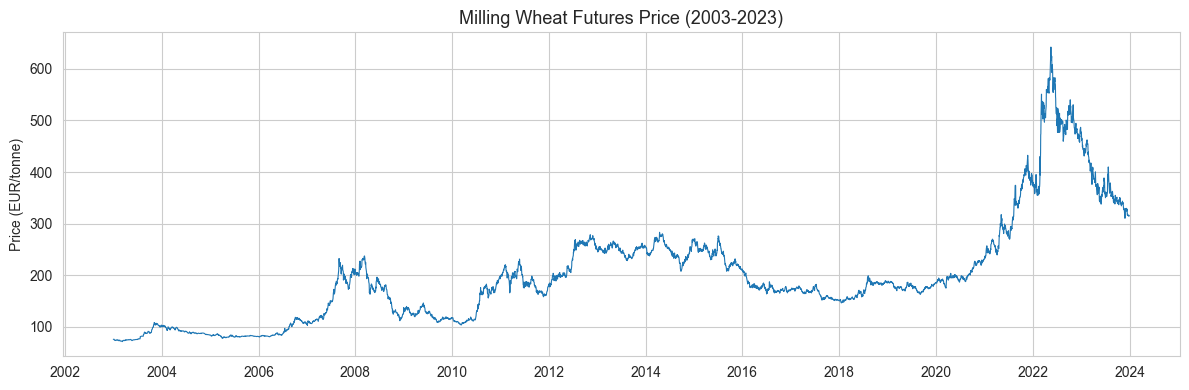

In [52]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(futures['Date'], futures['Price'], linewidth=0.8)
ax.set_title('Milling Wheat Futures Price (2003-2023)', fontsize=13)
ax.set_ylabel('Price (EUR/tonne)')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

---
## 2. Create Target Variable and Price-Only Features

In [53]:
# ============================================================
# Target: continuous 5-day forward return (regression)
# ============================================================
futures['Fwd_Return'] = futures['Price'].shift(-FORECAST_HORIZON) / futures['Price'] - 1

# ============================================================
# MINIMAL price features: returns + volume only
#
# We deliberately strip price features to the bare minimum.
# The goal is to isolate whether AGRICULTURAL data from
# CY-Bench adds predictive signal, not to build the best
# possible price-based model. If we included RSI, SMAs,
# Bollinger bands etc., any lift from ag features could be
# confounded with price feature interactions.
#
# We keep only:
#   - ret_5d: 1-week momentum (same horizon as target)
#   - ret_20d: 1-month momentum (medium-term trend)
#   - vol_sma_ratio: relative volume (liquidity/attention)
#
# These 3 features form a minimal "market state" control.
# ============================================================

futures['ret_5d'] = futures['Price'].pct_change(5)
futures['ret_20d'] = futures['Price'].pct_change(20)
futures['vol_sma_ratio'] = futures['Volume'] / futures['Volume'].rolling(20).mean()

price_feature_cols = ['ret_5d', 'ret_20d', 'vol_sma_ratio']
print(f"Price features ({len(price_feature_cols)}): {price_feature_cols}")

Price features (3): ['ret_5d', 'ret_20d', 'vol_sma_ratio']


---
## 3. Load CY-Bench Agricultural Data (FR, DE, PL)

We load data for all three major EU wheat producers. Unlike the previous version
which aggregated regions immediately, here we **keep each region separate** -
each region will become a candidate for per-region modelling.

In [43]:
# ============================================================
# Generic CY-Bench loader for any country
# ============================================================

def load_cybench_csv(directory, pattern):
    matches = glob.glob(os.path.join(directory, pattern))
    if not matches:
        return None
    df = pd.read_csv(matches[0])
    return df

def load_country_data(country_code, cybench_dir):
    """
    Load all CY-Bench CSVs for a given country code.
    Returns dict of DataFrames keyed by data type.
    """
    possible = [
        os.path.join(cybench_dir, country_code),
        os.path.join(cybench_dir, 'EU'),
        cybench_dir,
    ]
    data_dir = None
    for p in possible:
        if os.path.isdir(p):
            pattern = f'meteo_wheat_{country_code}.csv'
            if glob.glob(os.path.join(p, pattern)):
                data_dir = p
                break

    if data_dir is None:
        print(f"  {country_code}: Data not found, skipping.")
        return None

    print(f"  {country_code}: Loading from {data_dir}")
    datasets = {}
    for var, pat in [('meteo', f'meteo_wheat_{country_code}.csv'),
                     ('soil_moisture', f'soil_moisture_wheat_{country_code}.csv'),
                     ('ndvi', f'ndvi_wheat_{country_code}.csv'),
                     ('fpar', f'fpar_wheat_{country_code}.csv')]:
        df = load_cybench_csv(data_dir, pat)
        if df is not None:
            # Filter to country regions
            if 'adm_id' in df.columns:
                df = df[df['adm_id'].astype(str).str.startswith(country_code)].copy()
            datasets[var] = df
            print(f"    {var}: {df.shape}, {df['adm_id'].nunique()} regions")

    # Load yield data for production weights
    yield_df = load_cybench_csv(data_dir, f'yield_wheat_{country_code}.csv')
    if yield_df is not None and 'adm_id' in yield_df.columns:
        yield_df = yield_df[yield_df['adm_id'].astype(str).str.startswith(country_code)].copy()
        datasets['yield'] = yield_df
        print(f"    yield: {yield_df.shape}, {yield_df['adm_id'].nunique()} regions")

    return datasets

# Load all three countries
print("Loading CY-Bench agricultural data\n")
country_data = {}

# We focus on the EU's 3 largest producers
countries = ['FR', 'DE', 'PL']

for country in countries:
    data = load_country_data(country, CYBENCH_DATA_DIR)
    if data is not None:
        country_data[country] = data
    print()

print(f"Countries loaded: {list(country_data.keys())}")
for country, data in country_data.items():
    n_regions = set()
    for k, df in data.items():
        if 'adm_id' in df.columns:
            n_regions.update(df['adm_id'].unique())
    print(f"  {country}: {len(n_regions)} unique regions, data types: {list(data.keys())}")

Loading CY-Bench agricultural data

  FR: Loading from cy-bench\FR
    meteo: (814800, 11), 97 regions
    soil_moisture: (740886, 5), 97 regions
    ndvi: (97951, 4), 97 regions
    fpar: (80316, 4), 97 regions
    yield: (2571, 7), 95 regions

  DE: Loading from cy-bench\DE
    meteo: (3368400, 11), 401 regions
    soil_moisture: (3055200, 5), 400 regions
    ndvi: (350540, 4), 401 regions
    fpar: (332028, 4), 401 regions
    yield: (15233, 12), 397 regions

  PL: Loading from cy-bench\PL
    meteo: (142800, 11), 17 regions
    soil_moisture: (129846, 5), 17 regions
    ndvi: (16115, 4), 17 regions
    fpar: (14076, 4), 17 regions
    yield: (301, 7), 17 regions

Countries loaded: ['FR', 'DE', 'PL']
  FR: 98 unique regions, data types: ['meteo', 'soil_moisture', 'ndvi', 'fpar', 'yield']
  DE: 401 unique regions, data types: ['meteo', 'soil_moisture', 'ndvi', 'fpar', 'yield']
  PL: 17 unique regions, data types: ['meteo', 'soil_moisture', 'ndvi', 'fpar', 'yield']


---
## 4. Process Agricultural Data: Per-Region Daily Expansion

**Critical difference from the aggregated approach:** We do NOT average across
regions. Instead, for each region we:

1. Parse the date column (YYYYMMDD string)
2. Forward-fill to daily frequency (LOCF - last observation carried forward)
3. Keep the region identifier so we can build per-region models later

This follows Paudel et al. (2022, Section 2): "Machine learning models were built
per crop and country, i.e. data for all regions within a country were pooled to
build a model for that country."

However, we go further: we build **one model per region** and then aggregate
predictions, which Chipanshi et al. (2015) showed produces better results than
aggregating predictors first (cited in Paudel et al. 2022, Section 1).

In [7]:
# ============================================================
# Step 4a: Build production weights per region
#
# Production weights serve TWO purposes:
#   1. Aggregating per-region predictions to EU level
#      (Paudel et al. 2022, Section 2.5.3)
#   2. Informing which regions matter economically
#
# We use PREVIOUS year's production to avoid look-ahead bias.
#
# HANDLING INCOMPLETE DATA (Germany):
#   Germany's CY-Bench data has:
#     - yield:        available every year
#     - harvest_area: available only every ~4 years (census)
#     - production:   entirely NaN
#   France/Poland have all three columns filled.
#
#   Solution (following user specification):
#     1. Forward-fill harvest_area within each region
#        (area changes slowly between censuses)
#     2. Compute production = yield * harvest_area
#   This is standard practice: Eurostat publishes area data
#   less frequently than yield, and interpolation/carry-forward
#   is the norm in operational systems (Cerrani & López Lozano,
#   2017).
#
# HANDLING SHORT TIME SERIES:
#   Some regions stop reporting before 2023 (e.g., France stops
#   at 2020, some German regions earlier). We use the most
#   recent available production as fallback.
# ============================================================

production_weights = {}  # {adm_id: {year: production_tonnes}}

for cc, data in country_data.items():
    if 'yield' not in data:
        continue
    ydf = data['yield'].copy()

    # Ensure columns exist
    if 'yield' not in ydf.columns:
        continue

    # --- Handle missing harvest_area and production ---
    # Check which area column exists (FR uses 'harvest_area', DE also)
    area_col = None
    for candidate in ['harvest_area', 'planted_area']:
        if candidate in ydf.columns:
            area_col = candidate
            break

    if area_col is not None:
        # Forward-fill harvest_area within each region
        # (area changes slowly; census every ~4 years for DE)
        ydf = ydf.sort_values(['adm_id', 'harvest_year'])
        ydf[area_col] = ydf.groupby('adm_id')[area_col].ffill()
        # Also backward-fill to cover years before first census
        ydf[area_col] = ydf.groupby('adm_id')[area_col].bfill()

    # Compute production where missing
    if 'production' not in ydf.columns:
        ydf['production'] = np.nan

    missing_prod = ydf['production'].isna()
    if missing_prod.any() and area_col is not None:
        ydf.loc[missing_prod, 'production'] = (
            ydf.loc[missing_prod, 'yield'] * ydf.loc[missing_prod, area_col]
        )
        n_filled = missing_prod.sum() - ydf['production'].isna().sum()
        print(f"  {cc}: Filled {n_filled} missing production values "
              f"(yield * forward-filled {area_col})")

    # Remaining NaN in production (no area data at all)
    still_missing = ydf['production'].isna().sum()
    if still_missing > 0:
        print(f"  {cc}: {still_missing} rows still missing production "
              f"(no area data available)")

    # Build the weights dictionary
    for _, row in ydf.iterrows():
        adm = row['adm_id']
        yr = row['harvest_year']
        prod = row['production']
        if pd.notna(prod) and prod > 0:
            if adm not in production_weights:
                production_weights[adm] = {}
            production_weights[adm][yr] = prod

    n_regions = len([r for r in production_weights if r.startswith(cc)])
    print(f"  {cc}: {n_regions} regions with production weights")

print(f"\nTotal regions with production weights: {len(production_weights)}")
for cc in country_data:
    cc_regions = [r for r in production_weights if r.startswith(cc)]
    if cc_regions:
        # Show year coverage
        all_years = set()
        for r in cc_regions:
            all_years.update(production_weights[r].keys())
        print(f"  {cc}: {len(cc_regions)} regions, "
              f"years {min(all_years)}-{max(all_years)}")

# Helper: get production weight for a region in a given year
# Uses previous year's production (lag 1 year to avoid look-ahead)
def get_production_weight(adm_id, year):
    if adm_id not in production_weights:
        return 0.0
    prev_year = year - 1
    if prev_year in production_weights[adm_id]:
        return production_weights[adm_id][prev_year]
    # Fallback: use nearest earlier available year
    available = sorted(production_weights[adm_id].keys())
    earlier = [y for y in available if y < year]
    if earlier:
        return production_weights[adm_id][earlier[-1]]
    # Last resort: use earliest available
    if available:
        return production_weights[adm_id][available[0]]
    return 0.0

  FR: 95 regions with production weights
  DE: Filled 15223 missing production values (yield * forward-filled harvest_area)
  DE: 10 rows still missing production (no area data available)
  DE: 396 regions with production weights
  PL: 17 regions with production weights

Total regions with production weights: 508
  FR: 95 regions, years 1989-2020
  DE: 396 regions, years 1979-2021
  PL: 17 regions, years 2003-2020


# ============================================================
# Step 4b: Process time-series data PER REGION
#
# For each region, we:
#   1. Parse dates
#   2. Combine all data types (meteo, soil, ndvi, fpar)
#   3. Forward-fill to daily frequency
#   4. Store as {adm_id: DataFrame}
#
# NO cross-regional aggregation at this stage.
# ============================================================

def process_region_timeseries(df, name):
    """Parse dates and identify variable columns."""
    if df is None or df.empty:
        return None
    df = df.copy()
    meta_cols = {'adm_id', 'crop_name', 'country_code', 'date',
                 'harvest_year', 'yield', 'harvest_area', 'production',
                 'sos', 'eos', 'crop_area', 'crop_area_percentage',
                 'region_area', 'geometry'}
    var_cols = [c for c in df.columns if c not in meta_cols]
    if 'date' not in df.columns:
        return None
    df['date'] = pd.to_datetime(df['date'], format='%Y%m%d', errors='coerce')
    df = df.dropna(subset=['date'])
    for c in var_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    return df[['adm_id', 'date'] + var_cols], var_cols

def build_region_daily(datasets, country_code):
    """
    Build per-region daily DataFrames from CY-Bench data.
    Returns dict: {adm_id: DataFrame with date + variable columns}
    """
    # Process each data type
    processed = {}
    for dtype in ['meteo', 'soil_moisture', 'ndvi', 'fpar']:
        if dtype not in datasets:
            continue
        result = process_region_timeseries(datasets[dtype], f"{country_code}_{dtype}")
        if result is not None:
            df, var_cols = result
            # Prefix variable names with dtype
            rename = {c: f'{dtype}_{c}' for c in var_cols}
            df = df.rename(columns=rename)
            processed[dtype] = df

    if not processed:
        return {}

    # Get all regions across data types
    all_regions = set()
    for df in processed.values():
        all_regions.update(df['adm_id'].unique())

    # Build per-region combined DataFrames
    region_dfs = {}
    for region in sorted(all_regions):
        dfs_for_region = []
        for dtype, df in processed.items():
            rdf = df[df['adm_id'] == region].drop(columns=['adm_id']).copy()
            if len(rdf) == 0:
                continue
            rdf = rdf.sort_values('date')
            dfs_for_region.append(rdf)

        if not dfs_for_region:
            continue

        # Merge all data types on date
        combined = dfs_for_region[0]
        for df in dfs_for_region[1:]:
            combined = combined.merge(df, on='date', how='outer')
        combined = combined.sort_values('date')

        # Expand to daily with LOCF
        full_dates = pd.date_range(combined['date'].min(),
                                    combined['date'].max(), freq='D')
        combined = combined.set_index('date').reindex(full_dates).ffill()
        combined = combined.reset_index().rename(columns={'index': 'date'})

        region_dfs[region] = combined

    return region_dfs


# Build per-region daily data for all countries
print("Building per-region daily datasets...\n")
all_region_dfs = {}  # {adm_id: DataFrame}

for cc, data in country_data.items():
    region_dfs = build_region_daily(data, cc)
    all_region_dfs.update(region_dfs)
    print(f"  {cc}: {len(region_dfs)} regions processed")
    if region_dfs:
        sample_region = list(region_dfs.keys())[0]
        sample_df = region_dfs[sample_region]
        n_feats = len([c for c in sample_df.columns if c != 'date'])
        print(f"    Sample region {sample_region}: {sample_df.shape[0]} days, "
              f"{n_feats} features")
        print(f"    Date range: {sample_df['date'].min().date()} to "
              f"{sample_df['date'].max().date()}")

print(f"\nTotal regions across all countries: {len(all_region_dfs)}")

# ============================================================
# Save per-region daily data to CSV
#
# One CSV per region: {adm_id}_daily.csv
# Also save a summary index CSV listing all regions.
# ============================================================

REGION_DATA_DIR = "region_daily_data"
os.makedirs(REGION_DATA_DIR, exist_ok=True)

summary_rows = []
for adm_id, df in sorted(all_region_dfs.items()):
    path = os.path.join(REGION_DATA_DIR, f"{adm_id}_daily.csv")
    df.to_csv(path, index=False)
    n_feats = len([c for c in df.columns if c != 'date'])
    summary_rows.append({
        'adm_id': adm_id,
        'country': adm_id[:2],
        'n_days': len(df),
        'n_features': n_feats,
        'date_min': df['date'].min().date(),
        'date_max': df['date'].max().date(),
    })

summary = pd.DataFrame(summary_rows)
summary.to_csv(os.path.join(REGION_DATA_DIR, "_region_index.csv"), index=False)

print(f"Saved {len(summary)} region CSVs to '{REGION_DATA_DIR}/'")
print(f"Index file: {REGION_DATA_DIR}/_region_index.csv\n")
print(summary.groupby('country').agg(
    regions=('adm_id', 'count'),
    avg_days=('n_days', 'mean'),
    avg_features=('n_features', 'mean'),
).to_string())

import pandas as pd
import os

REGION_DATA_DIR = "region_daily_data"

rows = []
for fname in sorted(os.listdir(REGION_DATA_DIR)):
    if fname.startswith('_') or not fname.endswith('_daily.csv'):
        continue
    adm_id = fname.replace('_daily.csv', '')
    df = pd.read_csv(os.path.join(REGION_DATA_DIR, fname), parse_dates=['date'])
    n_feats = len([c for c in df.columns if c != 'date'])
    rows.append({
        'adm_id': adm_id,
        'country': adm_id[:2],
        'n_days': len(df),
        'n_features': n_feats,
        'date_min': df['date'].min().date(),
        'date_max': df['date'].max().date(),
    })

index_df = pd.DataFrame(rows)
index_df.to_csv(os.path.join(REGION_DATA_DIR, "_region_index.csv"), index=False)

print(f"Rebuilt index: {len(index_df)} regions")
print(index_df.groupby('country')['adm_id'].count().to_string())

In [8]:
# ============================================================
# Load pre-generated per-region daily CSVs
#
# Skips: CY-Bench loading, parsing, daily expansion, saving
# Requires: the region_daily_data/ folder from a previous run
# Only loads regions from countries in the countries list.
# ============================================================

REGION_DATA_DIR = "region_daily_data"

# --- Load region index ---
index_path = os.path.join(REGION_DATA_DIR, "_region_index.csv")
region_index = pd.read_csv(index_path)
print(f"Found {len(region_index)} total regions in '{REGION_DATA_DIR}/'")

# --- Filter to countries list ---
region_index = region_index[region_index['country'].isin(countries)]
print(f"After filtering to {countries}: {len(region_index)} regions")

# --- Load region CSVs into all_region_dfs ---
all_region_dfs = {}
for _, row in region_index.iterrows():
    adm_id = row['adm_id']
    path = os.path.join(REGION_DATA_DIR, f"{adm_id}_daily.csv")
    df = pd.read_csv(path, parse_dates=['date'])
    all_region_dfs[adm_id] = df

print(f"Loaded {len(all_region_dfs)} regions")
print(f"countries: {region_index.groupby('country')['adm_id'].count().to_dict()}")

Found 659 total regions in 'region_daily_data/'
After filtering to ['FR', 'DE', 'PL']: 515 regions
Loaded 515 regions
countries: {'DE': 401, 'FR': 97, 'PL': 17}


---
## 4c. Per-Region Feature Engineering

Following CY-Bench (Paudel et al., 2025, Section 2.2.3) recommendations:
*"time series data are aggregated in the temporal dimension to create
domain-relevant features... monthly averages of tmin, tmax, tavg, prec,
cumulative CWB... monthly maximum values for cumulative GDD, cumul prec,
cumul fPAR, cumul NDVI... number of cold days, hot days, dry days."*

We apply these feature transformations to EACH region individually before
any cross-regional aggregation. This preserves region-specific signals
(e.g., drought in Beauce vs normal conditions in Brittany) that would be
lost if we aggregated raw features first.

In [9]:
# ============================================================
# Per-region feature engineering
#
# For each region's daily DataFrame, we compute:
#   1. Rolling means and cumulative sums (30d, 60d windows)
#   2. Threshold-based stress indicators (CY-Bench: cold/hot/dry days)
#   3. NDVI/fPAR anomalies (relative to expanding DOY climatology)
#   4. Phenological phase indicators (based on month)
#   5. Cross-variable interactions (VPD stress, DTR)
#
# CY-Bench Section 2.2.3: "Following expert recommendations we create
# monthly averages... cumulative growing degree days, cumulative
# precipitation, cumulative fPAR and cumulative NDVI... number of days
# in which tmin < 0 ('cold days'), tmax > 35 ('hot days'), prec < 1mm
# ('dry days')."
# ============================================================

def engineer_region_features(df):
    """
    Apply feature engineering to a single region's daily DataFrame.
    Input: DataFrame with 'date' column and raw CY-Bench variables.
    Output: DataFrame with original + engineered features.
    """
    df = df.copy().sort_values('date').set_index('date')
    month = df.index.month

    # ============================================================
    # A. PHENOLOGICAL PHASE INDICATORS
    # Binary flags for which crop phase we're in.
    # French winter wheat phenology:
    #   Sowing → Emergence: Oct-Nov
    #   Dormancy / Vernalisation: Dec-Feb
    #   Stem elongation: Mar-Apr
    #   Heading / Flowering: May
    #   Grain filling: Jun-Jul
    # ============================================================
    df['in_growing_season'] = ((month >= 10) | (month <= 7)).astype(float)
    df['phase_dormant'] = ((month >= 12) | (month <= 2)).astype(float)
    df['phase_stem_elong'] = ((month >= 3) & (month <= 4)).astype(float)
    df['phase_flowering'] = (month == 5).astype(float)
    df['phase_grain_fill'] = ((month >= 6) & (month <= 7)).astype(float)

    # ============================================================
    # B. PHASE-CONDITIONAL STRESS FEATURES
    # These only accumulate stress during vulnerable windows.
    # ============================================================

    # --- Vernalisation frost stress (Dec-Feb): days < -10°C ---
    if 'meteo_tmin' in df.columns:
        frost_mask = df['phase_dormant'] * (df['meteo_tmin'] < -10).astype(float)
        df['winterkill_risk_30d'] = frost_mask.rolling(30, min_periods=5).sum()
        df['winterkill_risk_60d'] = frost_mask.rolling(60, min_periods=5).sum()
        # Milder frost days (< -5°C) during dormancy
        mild_frost = df['phase_dormant'] * (df['meteo_tmin'] < -5).astype(float)
        df['frost_days_dormant_60d'] = mild_frost.rolling(60, min_periods=5).sum()

    # --- Spring heat shock (Mar-May): days > 25°C ---
    if 'meteo_tmax' in df.columns:
        spring_heat = ((month >= 3) & (month <= 5)).astype(float) * (df['meteo_tmax'] > 25).astype(float)
        df['spring_heat_days_30d'] = spring_heat.rolling(30, min_periods=5).sum()
        df['spring_heat_days_60d'] = spring_heat.rolling(60, min_periods=5).sum()

    # --- Grain-fill heat stress (May-Jul): days > 30°C ---
    # Schlenker & Roberts (2009): nonlinear temperature effects
    # indicate severe damages to US crop yields
    if 'meteo_tmax' in df.columns:
        gf_heat = ((month >= 5) & (month <= 7)).astype(float) * (df['meteo_tmax'] > 30).astype(float)
        df['grainfill_heat_days_30d'] = gf_heat.rolling(30, min_periods=5).sum()
        # Cumulative excess heat above 30°C during grain fill
        gf_excess = ((month >= 5) & (month <= 7)).astype(float) * (df['meteo_tmax'] - 30).clip(lower=0)
        df['grainfill_excess_heat_30d'] = gf_excess.rolling(30, min_periods=5).sum()

    # --- CY-Bench threshold indicators (Paudel et al. 2025, §2.2.3) ---
    # "number of days tmin < 0°C ('cold days'), tmax > 35°C ('hot days'),
    #  prec < 1mm ('dry days')"
    if 'meteo_tmin' in df.columns:
        df['cold_days_30d'] = (df['meteo_tmin'] < 0).astype(float).rolling(30, min_periods=5).sum()
    if 'meteo_tmax' in df.columns:
        df['hot_days_30d'] = (df['meteo_tmax'] > 35).astype(float).rolling(30, min_periods=5).sum()
    if 'meteo_prec' in df.columns:
        df['dry_days_30d'] = (df['meteo_prec'] < 1).astype(float).rolling(30, min_periods=5).sum()

    # --- Flowering drought (Apr-Jun): cumul water deficit ---
    if 'meteo_cwb' in df.columns:
        flower_cwb = df['meteo_cwb'].copy()
        flower_cwb[~((month >= 4) & (month <= 6))] = 0
        df['flowering_drought_60d'] = flower_cwb.rolling(60, min_periods=5).sum()
        df['flowering_drought_90d'] = flower_cwb.rolling(90, min_periods=5).sum()

    # ============================================================
    # C. NDVI ANOMALY - "crop health surprise"
    # How does current NDVI compare to what's normal for this
    # time of year? Low NDVI in Jan = normal (dormant).
    # Low NDVI in May = disaster. We compute the anomaly
    # relative to the historical day-of-year mean.
    # Expanding climatology avoids future leakage.
    # ============================================================
    if 'ndvi_ndvi' in df.columns:
        df['doy'] = df.index.dayofyear
        ndvi_clim = df.groupby('doy')['ndvi_ndvi'].expanding().mean()
        ndvi_clim = ndvi_clim.reset_index(level=0, drop=True).sort_index()
        df['ndvi_anomaly'] = df['ndvi_ndvi'] - ndvi_clim
        df['ndvi_anomaly_30d'] = df['ndvi_anomaly'].rolling(30, min_periods=5).mean()
        df = df.drop(columns=['doy'])

    if 'fpar_fpar' in df.columns:
        df['fpar_doy'] = df.index.dayofyear
        fpar_clim = df.groupby('fpar_doy')['fpar_fpar'].expanding().mean()
        fpar_clim = fpar_clim.reset_index(level=0, drop=True).sort_index()
        df['fpar_anomaly'] = df['fpar_fpar'] - fpar_clim
        df['fpar_anomaly_30d'] = df['fpar_anomaly'].rolling(30, min_periods=5).mean()
        df = df.drop(columns=['fpar_doy'])

    # ============================================================
    # D. COMPACT ROLLING FEATURES
    # 30 and 60-day windows on key variables.
    # CY-Bench (Paudel et al. 2025, §2.2.3): "monthly averages of
    # tmin, tmax, tavg, prec, cumulative CWB... cumulative GDD,
    # cumulative precipitation, cumulative fPAR, cumulative NDVI"
    # ============================================================
    key_vars = [v for v in ['meteo_tavg', 'meteo_tmin', 'meteo_tmax',
                            'meteo_prec', 'meteo_vpd', 'meteo_cwb',
                            'soil_moisture_ssm', 'ndvi_ndvi', 'fpar_fpar']
                if v in df.columns]
    for window in [30, 60]:
        for var in key_vars:
            df[f'{var}_mean_{window}d'] = df[var].rolling(window, min_periods=10).mean()

    # Cumulative precipitation
    if 'meteo_prec' in df.columns:
        for window in [30, 60]:
            df[f'cumul_prec_{window}d'] = df['meteo_prec'].rolling(window, min_periods=10).sum()

    # Growing degree days (base 0°C)
    if 'meteo_tavg' in df.columns:
        gdd_daily = df['meteo_tavg'].clip(lower=0)
        for window in [30, 60]:
            df[f'gdd_cumul_{window}d'] = gdd_daily.rolling(window, min_periods=10).sum()

    # ============================================================
    # E. WEEKEND WEATHER ACCUMULATOR
    # Futures don't trade Sat/Sun but weather happens. On Monday,
    # the market reacts to 3 days of news (Fri evening + weekend).
    # ============================================================
    df['is_monday'] = (df.index.dayofweek == 0).astype(float)
    if 'meteo_prec' in df.columns:
        df['weekend_prec'] = df['meteo_prec'].rolling(3, min_periods=1).sum() * df['is_monday']
    if 'meteo_tmax' in df.columns:
        df['weekend_tmax'] = df['meteo_tmax'].rolling(3, min_periods=1).max() * df['is_monday']
    if 'meteo_tmin' in df.columns:
        df['weekend_tmin'] = df['meteo_tmin'].rolling(3, min_periods=1).min() * df['is_monday']

    # ============================================================
    # F. STANDARDISED PRECIPITATION INDEX (SPI-like)
    # Z-score of rolling precipitation relative to its expanding
    # historical distribution. Positive = wetter than normal,
    # negative = drought.
    # (McKee et al., 1993; widely used in drought monitoring)
    # ============================================================
    if 'meteo_prec' in df.columns:
        for window in [30, 60]:
            roll_prec = df['meteo_prec'].rolling(window, min_periods=10).sum()
            spi_mean = roll_prec.expanding(min_periods=60).mean()
            spi_std = roll_prec.expanding(min_periods=60).std()
            df[f'spi_{window}d'] = (roll_prec - spi_mean) / spi_std.replace(0, np.nan)

    # ============================================================
    # G. DIURNAL TEMPERATURE RANGE (DTR)
    # Large DTR indicates clear skies (drought risk); small DTR
    # indicates cloud cover (rain). Used in crop-climate studies.
    # (Lobell, 2007; Laudien et al., 2023)
    # ============================================================
    if 'meteo_tmax' in df.columns and 'meteo_tmin' in df.columns:
        df['dtr'] = df['meteo_tmax'] - df['meteo_tmin']
        df['dtr_mean_30d'] = df['dtr'].rolling(30, min_periods=10).mean()
        df['dtr_anomaly_30d'] = df['dtr'] - df['dtr'].expanding(min_periods=60).mean()

    # ============================================================
    # H. VPD-BASED DROUGHT STRESS INDEX
    # Vapour pressure deficit is a stronger predictor of crop
    # stress than temperature alone. High VPD = plant stomata
    # close = photosynthesis stops = yield loss.
    # (Lobell et al., 2014; Schlenker & Roberts, 2009)
    # ============================================================
    if 'meteo_vpd' in df.columns:
        vpd_critical = df['meteo_vpd'].copy()
        vpd_critical[~((month >= 3) & (month <= 7))] = 0
        df['vpd_stress_critical_30d'] = vpd_critical.rolling(30, min_periods=5).mean()
        df['vpd_stress_critical_60d'] = vpd_critical.rolling(60, min_periods=5).mean()
        # Days with VPD > 15 hPa (high atmospheric demand)
        df['high_vpd_days_30d'] = (df['meteo_vpd'] > 15).astype(float).rolling(30, min_periods=5).sum()

    # ============================================================
    # I. SOIL MOISTURE DEFICIT INDEX (SMDI-like)
    # Z-score of soil moisture relative to expanding climatology.
    # Negative = drier than normal.
    # (Narasimhan & Srinivasan, 2005)
    # ============================================================
    for sm_var in ['soil_moisture_ssm', 'soil_moisture_rsm']:
        if sm_var in df.columns:
            sm_mean = df[sm_var].expanding(min_periods=60).mean()
            sm_std = df[sm_var].expanding(min_periods=60).std()
            df[f'{sm_var}_zscore'] = (df[sm_var] - sm_mean) / sm_std.replace(0, np.nan)
            df[f'{sm_var}_zscore_30d'] = df[f'{sm_var}_zscore'].rolling(30, min_periods=5).mean()

    # ============================================================
    # J. RADIATION USE EFFICIENCY PROXY
    # FPAR * radiation ≈ absorbed photosynthetically active
    # radiation (APAR). Proxy for biomass accumulation rate.
    # (Monteith, 1972; widely used in crop models)
    # ============================================================
    if 'fpar_fpar' in df.columns and 'meteo_rad' in df.columns:
        df['apar_proxy'] = df['fpar_fpar'] * df['meteo_rad']
        df['apar_proxy_mean_30d'] = df['apar_proxy'].rolling(30, min_periods=10).mean()
        df['apar_doy'] = df.index.dayofyear
        apar_clim = df.groupby('apar_doy')['apar_proxy'].expanding().mean()
        apar_clim = apar_clim.reset_index(level=0, drop=True).sort_index()
        df['apar_anomaly'] = df['apar_proxy'] - apar_clim
        df = df.drop(columns=['apar_doy'])

    # ============================================================
    # K. TEMPERATURE OPTIMALITY INDEX
    # Wheat grows optimally at 15-22°C. We measure how far
    # current conditions deviate from this optimum.
    # (Porter & Gawith, 1999)
    # ============================================================
    if 'meteo_tavg' in df.columns:
        opt_low, opt_high = 15, 22
        temp = df['meteo_tavg']
        df['temp_suboptimal'] = np.where(
            temp < opt_low, opt_low - temp,
            np.where(temp > opt_high, temp - opt_high, 0)
        )
        df['temp_suboptimal_30d'] = df['temp_suboptimal'].rolling(30, min_periods=10).mean()
        # During critical phases only (Mar-Jul)
        subopt_critical = df['temp_suboptimal'].copy()
        subopt_critical[~((month >= 3) & (month <= 7))] = 0
        df['temp_suboptimal_critical_60d'] = subopt_critical.rolling(60, min_periods=10).mean()

    # ============================================================
    # Clean up: drop intermediate masking columns
    # Phase indicators (dormant, stem_elong, flowering) are KEPT
    # as features - they tell the model which crop phase we're in.
    # Only is_monday is dropped (used only for weekend accumulator).
    # ============================================================
    df = df.drop(columns=['is_monday'], errors='ignore')
    df = df.reset_index()

    return df


# Apply to all regions
print("Applying feature engineering to all regions.\n")
n_before = {}
for adm_id, df in all_region_dfs.items():
    n_before[adm_id] = len([c for c in df.columns if c != 'date'])
    all_region_dfs[adm_id] = engineer_region_features(df)

# Report
sample = list(all_region_dfs.keys())[0]
n_after = len([c for c in all_region_dfs[sample].columns if c != 'date'])
print(f"Feature engineering complete for {len(all_region_dfs)} regions")
print(f"  Before: ~{n_before[sample]} features per region")
print(f"  After:  ~{n_after} features per region (+{n_after - n_before[sample]} engineered)")

Applying feature engineering to all regions...

Feature engineering complete for 515 regions
  Before: ~12 features per region
  After:  ~76 features per region (+64 engineered)


Processing correlation matrices for 515 regions...
Total unique features found across all regions: 76


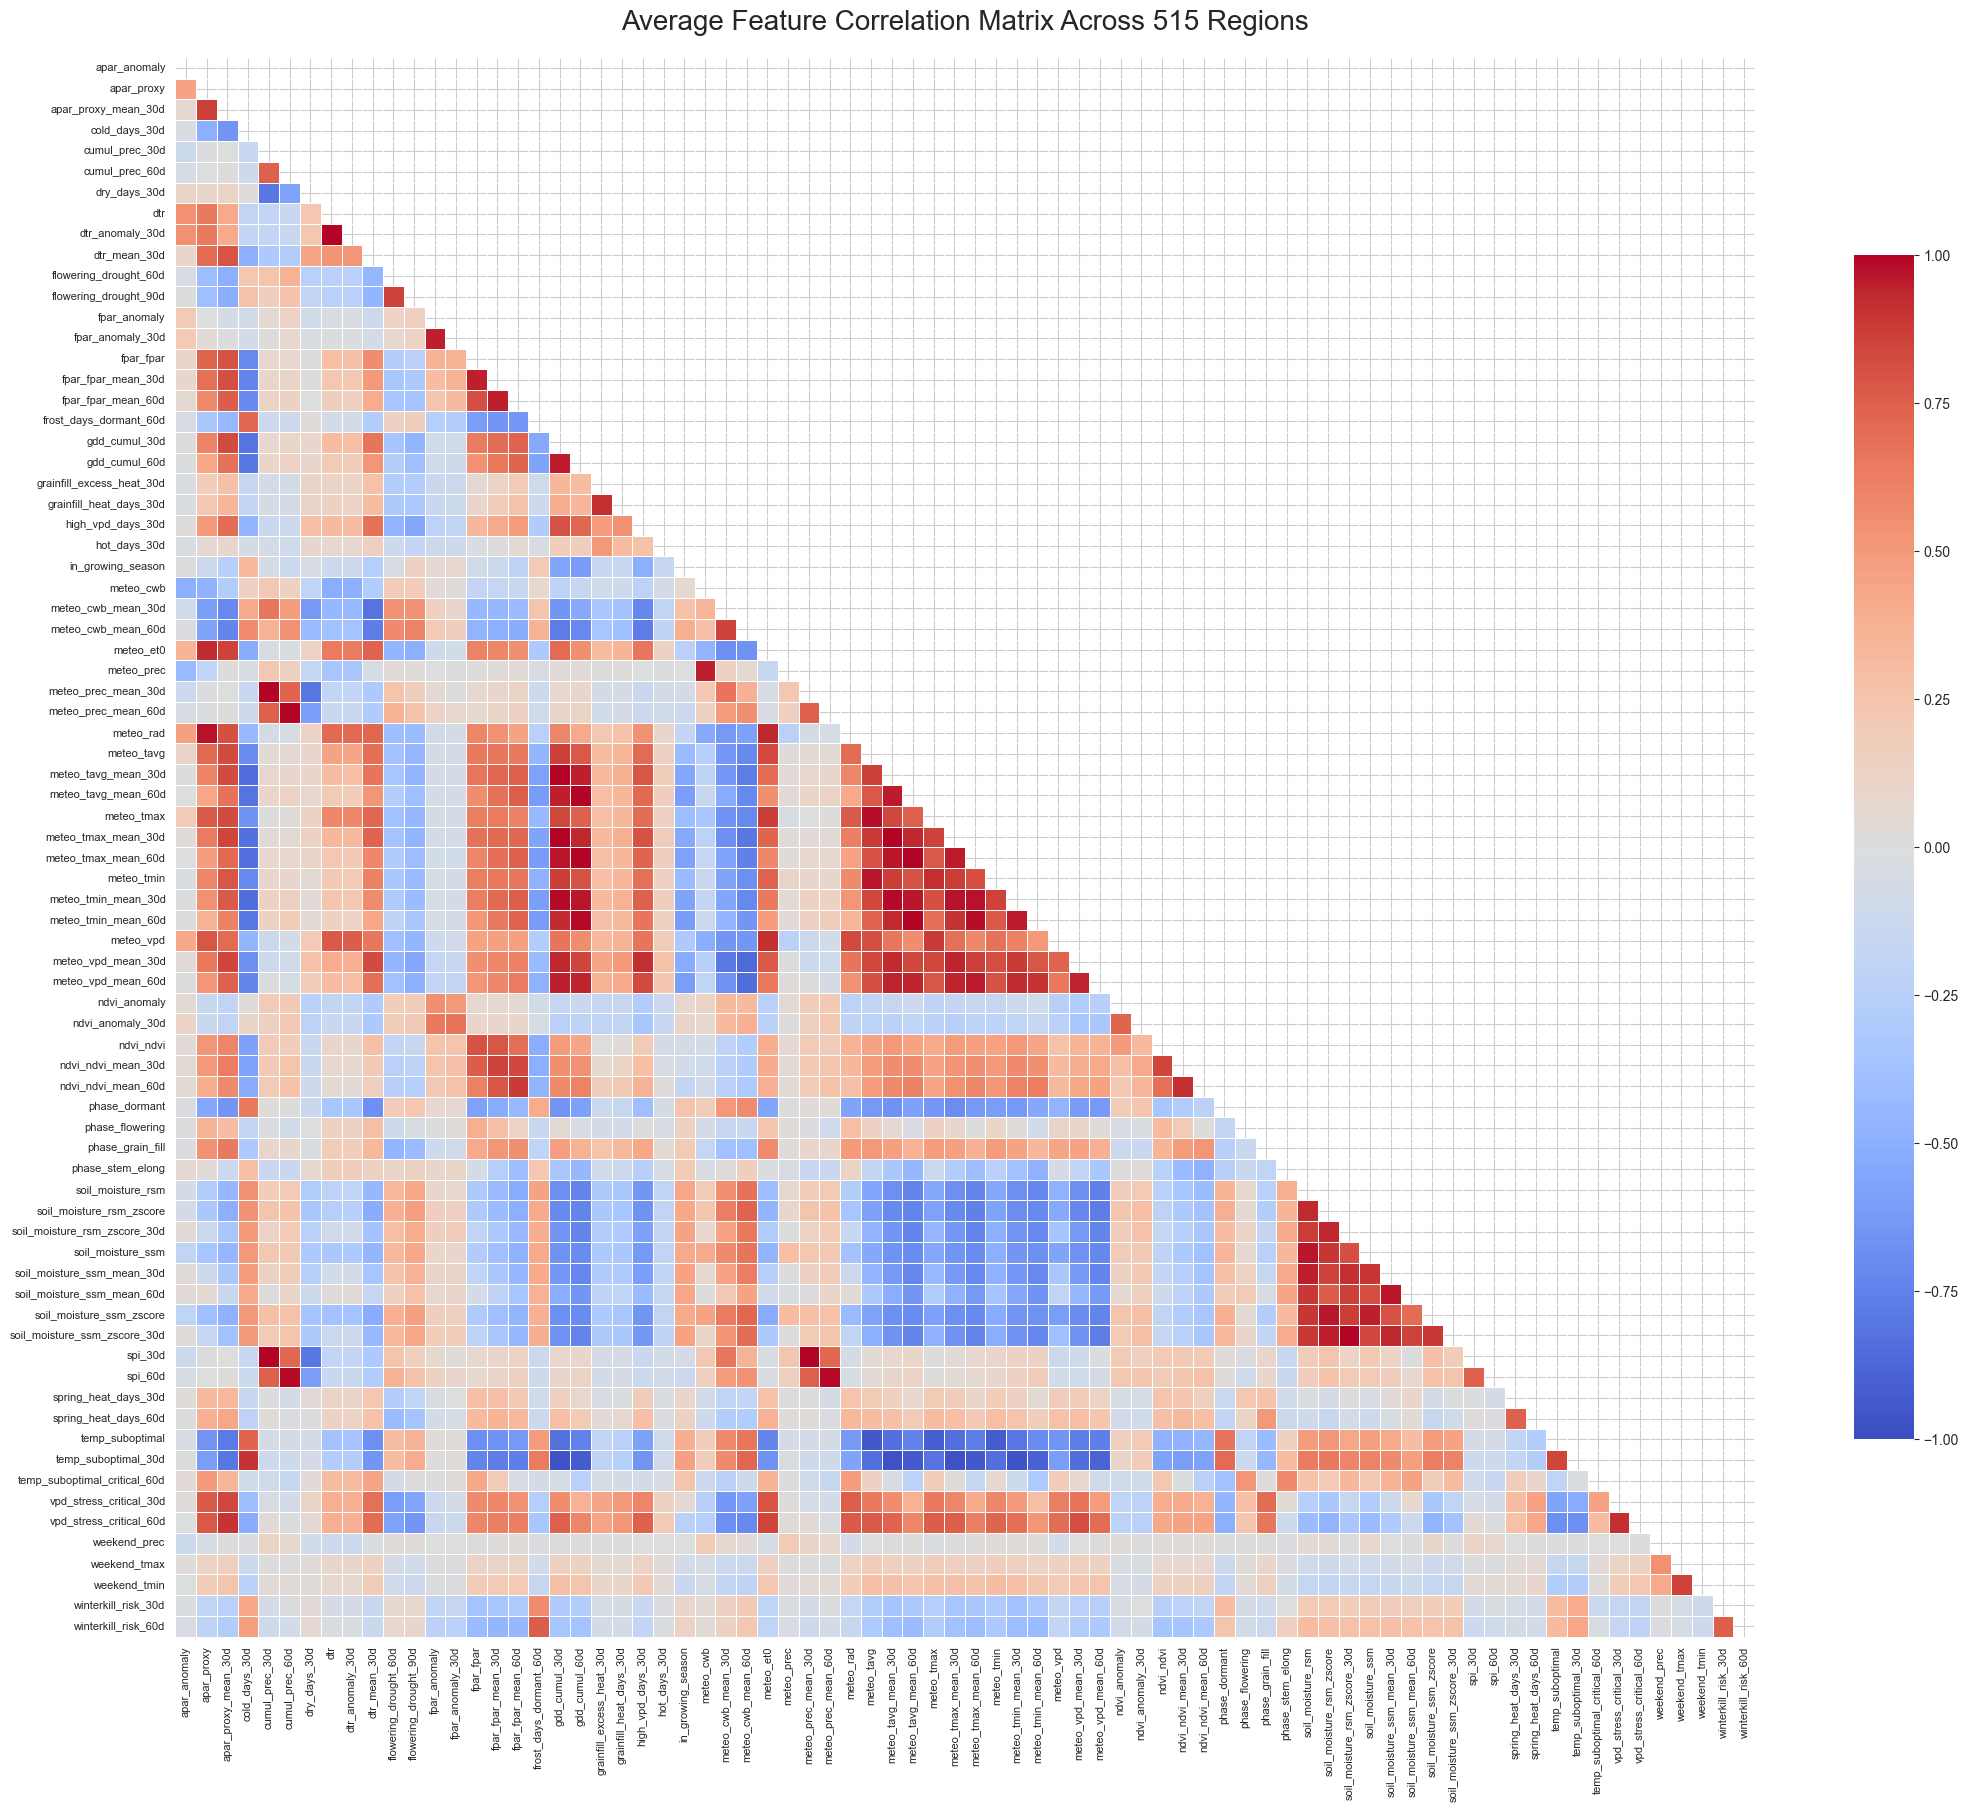

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def compute_average_correlation(region_dfs_dict):
    """
    Computes an average correlation matrix across multiple regions,
    handling missing features dynamically via reindexing.
    """
    fisher_z_matrices = []
    
    print(f"Processing correlation matrices for {len(region_dfs_dict)} regions...")
    
    
    # ------------------------------------------------------------
    # FIX STEP 1: Find the master list of all unique features
    # ------------------------------------------------------------
    master_features = set()
    for df in region_dfs_dict.values():
        cols = df.drop(columns=['date'], errors='ignore').select_dtypes(include=[np.number]).columns
        master_features.update(cols)
        
    master_features = sorted(list(master_features))
    print(f"Total unique features found across all regions: {len(master_features)}")
    
    # ------------------------------------------------------------
    # FIX STEP 2: Standardize all matrices to the master shape
    # ------------------------------------------------------------
    for adm_id, df in region_dfs_dict.items():
        feat_df = df.drop(columns=['date'], errors='ignore').select_dtypes(include=[np.number])
        
        # Calculate raw correlation
        corr = feat_df.corr()
        
        # Force the matrix to be exactly the size of master_features
        # Missing columns/rows become NaN automatically
        corr = corr.reindex(index=master_features, columns=master_features)
        
        # Apply Fisher Z-transform
        corr_vals = corr.values
        # Clip values to avoid infinity from arctanh(1.0), keeping NaNs intact
        corr_clipped = np.where(np.isnan(corr_vals), np.nan, np.clip(corr_vals, -0.9999, 0.9999))
        fisher_z = np.arctanh(corr_clipped)
        
        fisher_z_matrices.append(fisher_z)

    # ------------------------------------------------------------
    # Calculate the mean and Inverse Fisher Transform
    # ------------------------------------------------------------
    # Suppress warnings if an entire slice is NaN (e.g., a feature with zero variance)
    with np.errstate(invalid='ignore'):
        avg_z_matrix = np.nanmean(fisher_z_matrices, axis=0)
    
    avg_corr_matrix = np.tanh(avg_z_matrix)
    
    # Return standard DataFrame
    avg_corr_df = pd.DataFrame(avg_corr_matrix, index=master_features, columns=master_features)
    
    return avg_corr_df

# ==========================================
# Execute the corrected function
# ==========================================
avg_correlation_matrix = compute_average_correlation(all_region_dfs)

# ==========================================
# Visualization: The Heatmap
# ==========================================
plt.figure(figsize=(22, 18))

mask = np.triu(np.ones_like(avg_correlation_matrix, dtype=bool))

sns.heatmap(avg_correlation_matrix, 
            mask=mask, 
            cmap='coolwarm', 
            center=0, 
            vmin=-1, 
            vmax=1, 
            annot=False, 
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .75})

plt.title(f"Average Feature Correlation Matrix Across {len(all_region_dfs)} Regions", fontsize=20, pad=20)
plt.xticks(fontsize=8, rotation=90)
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
import numpy as np

def flag_highly_correlated_pairs(corr_matrix, threshold=0.85):
    """
    Scans a correlation matrix and returns a DataFrame of feature pairs 
    that exceed the absolute correlation threshold.
    """
    print(f"Scanning for feature pairs with absolute correlation > {threshold}...\n")
    
    # 1. Take the absolute value to catch both strong positive and negative correlations
    abs_corr = corr_matrix.abs()
    
    # 2. Mask the lower triangle and diagonal. 
    # This prevents flagging A-B and B-A as two separate issues, and ignores self-correlation (1.0).
    upper_tri = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))
    
    # 3. Extract the problematic pairs
    collinear_pairs = []
    for column in upper_tri.columns:
        # Find rows in this column that exceed the threshold
        high_corr_indices = upper_tri[column][upper_tri[column] > threshold].index
        
        for index in high_corr_indices:
            # Grab the original correlation value (with its positive/negative sign)
            original_corr_val = corr_matrix.loc[index, column]
            collinear_pairs.append({
                'Feature 1': index,
                'Feature 2': column,
                'Correlation': original_corr_val
            })
            
    # 4. Format the output
    results_df = pd.DataFrame(collinear_pairs)
    
    if results_df.empty:
        print("No highly correlated features found at this threshold.")
        return results_df, []
        
    # Sort by the most aggressively correlated pairs first
    results_df['Abs_Corr'] = results_df['Correlation'].abs()
    results_df = results_df.sort_values(by='Abs_Corr', ascending=False).drop(columns=['Abs_Corr']).reset_index(drop=True)
    
    # 5. Generate a simple "hit list" of features you can immediately drop
    # By simply taking 'Feature 2' from the pairs, we keep one version of the feature and drop the redundant one.
    features_to_drop = list(set(results_df['Feature 2']))
    
    print(f"Found {len(results_df)} highly correlated pairs.")
    print(f"Suggesting to drop {len(features_to_drop)} redundant features.")
    
    return results_df, features_to_drop

# ==========================================
# Execute the function
# ==========================================
# Assuming avg_correlation_matrix is already generated from the previous step
collinear_df, drop_list = flag_highly_correlated_pairs(avg_correlation_matrix, threshold=0.85)

# View the worst offenders
print("\nTop 10 most correlated pairs:")
print(collinear_df.head(10))

# View the exact list of features to exclude from your model
print("\nSuggested features to drop:")
print(drop_list)

Scanning for feature pairs with absolute correlation > 0.85...

Found 118 highly correlated pairs.
Suggesting to drop 41 redundant features.

Top 10 most correlated pairs:
                      Feature 1                     Feature 2  Correlation
0                cumul_prec_30d           meteo_prec_mean_30d     0.998870
1                           dtr               dtr_anomaly_30d     0.998794
2                 gdd_cumul_60d           meteo_tavg_mean_60d     0.997734
3                 gdd_cumul_30d           meteo_tavg_mean_30d     0.997218
4           meteo_tavg_mean_60d           meteo_tmax_mean_60d     0.996335
5           meteo_tavg_mean_30d           meteo_tmax_mean_30d     0.995374
6                 gdd_cumul_60d           meteo_tmax_mean_60d     0.993858
7  soil_moisture_rsm_zscore_30d  soil_moisture_ssm_zscore_30d     0.993801
8                cumul_prec_60d           meteo_prec_mean_60d     0.993376
9           meteo_tavg_mean_60d           meteo_tmin_mean_60d     0.993365

Su


```python
print(f"Dropping {len(drop_list)} highly correlated features from all {len(all_region_dfs)} regions...")

# Loop through your dictionary of DataFrames
for adm_id, df in all_region_dfs.items():
    # Drop the columns in the list
    # errors='ignore' ensures the code skips over any features that the specific region didn't generate
    all_region_dfs[adm_id] = df.drop(columns=drop_list, errors='ignore')

# ------------------------------------------------------------
# Quick Sanity Check
# ------------------------------------------------------------
sample_id = list(all_region_dfs.keys())[0]
# Count columns (subtracting 1 for the 'date' index/column)
remaining_features = len(all_region_dfs[sample_id].columns) - 1 

print("Feature pruning complete.")
print(f"Remaining features per region: ~{remaining_features} (down from 76)")
```

---
## 6. Merge and Model

We merge each cluster's aggregated features with futures data and evaluate
three approaches:

**A. Per-cluster models (Ridge, Lasso):** One model per cluster, predictions
production-weighted across clusters → EU forecast.

**B. Lasso stacking (Lecture 3 + Wolpert 1992):** Fit Ridge on each cluster
separately, then use Lasso to learn optimal combination weights. L1 penalty
drives uninformative clusters' weights to zero - implicit cluster selection.

**C. PCA regression (Lecture 10):** Stack all cluster features into one wide
matrix, apply PCA to extract EU-wide weather patterns, fit Ridge on top PCs.

In [54]:
# ============================================================
# Merge each region's features with futures
# ============================================================

futures_clean = futures.dropna(subset=['Fwd_Return'] + price_feature_cols).copy()
futures_sorted = futures_clean.sort_values('Date')

all_region_model_data = {}

for c, cdf in all_region_dfs.items():
    ag_sorted = cdf.sort_values('date')

    merged = pd.merge_asof(
        futures_sorted,
        ag_sorted,
        left_on='Date',
        right_on='date',
        direction='backward'
    )
    merged = merged.drop(columns=['date'], errors='ignore')

    ag_cols = [col for col in cdf.columns if col != 'date']
    for col in ag_cols:
        if col in merged.columns:
            merged[col] = merged[col].ffill().fillna(0)

    all_region_model_data[c] = {
        'df': merged.dropna(subset=['Fwd_Return'] + price_feature_cols).copy(),
        'ag_cols': ag_cols,
        'all_cols': price_feature_cols + ag_cols,
    }
    print(f"Region {c}: {merged.shape[0]} rows, "
          f"{len(ag_cols)} ag features, "
          f"{len(price_feature_cols)} price features")

region_members = {r: [r] for r in all_region_model_data}

Region DE111: 5364 rows, 76 ag features, 3 price features
Region DE112: 5364 rows, 76 ag features, 3 price features
Region DE113: 5364 rows, 76 ag features, 3 price features
Region DE114: 5364 rows, 76 ag features, 3 price features
Region DE115: 5364 rows, 76 ag features, 3 price features
Region DE116: 5364 rows, 76 ag features, 3 price features
Region DE117: 5364 rows, 76 ag features, 3 price features
Region DE118: 5364 rows, 76 ag features, 3 price features
Region DE119: 5364 rows, 76 ag features, 3 price features
Region DE11A: 5364 rows, 76 ag features, 3 price features
Region DE11B: 5364 rows, 76 ag features, 3 price features
Region DE11C: 5364 rows, 76 ag features, 3 price features
Region DE11D: 5364 rows, 76 ag features, 3 price features
Region DE121: 5364 rows, 76 ag features, 3 price features
Region DE122: 5364 rows, 76 ag features, 3 price features
Region DE123: 5364 rows, 76 ag features, 3 price features
Region DE124: 5364 rows, 76 ag features, 3 price features
Region DE125: 

In [45]:
# ============================================================
# Walk-forward regression
# ============================================================

def walk_forward_regression(df, feature_cols, model_class, model_kwargs,
                            test_start_year=2017, test_end_year=2023,
                            train_start_year=None, name="Model", verbose=False):
    df = df.copy()
    df['year'] = df['Date'].dt.year
    all_preds = []
    yearly_metrics = []

    for test_year in range(test_start_year, test_end_year + 1):
        train = df[df['year'] < test_year]
        if train_start_year:
            train = train[train['year'] >= train_start_year]
        test = df[df['year'] == test_year]
        if len(train) < 100 or len(test) < 20:
            continue
        train = train.dropna(subset=['Fwd_Return'])
        test = test.dropna(subset=['Fwd_Return'])
        if len(test) == 0:
            continue

        X_train = train[feature_cols].values
        y_train = train['Fwd_Return'].values
        X_test = test[feature_cols].values
        y_test = test['Fwd_Return'].values

        # Scaler fit INSIDE fold (Lecture 3: no leakage)
        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc = scaler.transform(X_test)

        model = model_class(**model_kwargs)
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)

        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        dir_acc = np.mean(np.sign(y_pred) == np.sign(y_test))
        yearly_metrics.append({'year': test_year, 'mse': mse, 'rmse': rmse,
                               'mae': mae, 'r2': r2, 'dir_acc': dir_acc})
        pred_df = test[['Date', 'Fwd_Return']].copy()
        pred_df['y_pred'] = y_pred
        all_preds.append(pred_df)

    if not yearly_metrics:
        return None
    metrics_df = pd.DataFrame(yearly_metrics)
    preds_df = pd.concat(all_preds, ignore_index=True)
    overall_mse = mean_squared_error(preds_df['Fwd_Return'], preds_df['y_pred'])
    overall = {
        'mse': overall_mse,
        'rmse': np.sqrt(overall_mse),
        'mae': mean_absolute_error(preds_df['Fwd_Return'], preds_df['y_pred']),
        'r2': r2_score(preds_df['Fwd_Return'], preds_df['y_pred']),
        'dir_acc': np.mean(np.sign(preds_df['y_pred']) == np.sign(preds_df['Fwd_Return']))
    }
    if verbose:
        print(f"  {name}: R2={overall['r2']:.4f}, Dir={overall['dir_acc']:.4f}, "
              f"RMSE={overall['rmse']:.6f}, MAE={overall['mae']:.6f}")
    return {'metrics_yearly': metrics_df, 'predictions': preds_df, 'overall': overall}

from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

test_start_year = 2017
test_end_year = 2023
print(f"Test period: {test_start_year}-{test_end_year}")

Test period: 2017-2023


In [46]:
# ============================================================
# Diebold-Mariano Test
#
# Diebold & Mariano (1995), "Comparing Predictive Accuracy,"
# Journal of Business & Economic Statistics, 13, 253-263.
#
# Tests H0: E[d_t] = 0 where d_t = L(e_t^A) - L(e_t^B)
# is the loss differential between two forecast methods.
#
# Uses Newey-West (HAC) standard errors to handle serial
# correlation in the loss differentials, which is expected
# with multi-step-ahead forecasts (h > 1).
#
# Harvey, Leybourne & Newbold (1997) small-sample correction
# is applied: adjusts the variance estimate and uses a
# t-distribution instead of standard normal.
# ============================================================
from scipy import stats

def diebold_mariano_test(actual, pred_1, pred_2, h=1, loss='mse'):
    """
    Diebold-Mariano test for equal predictive accuracy.
    
    Parameters
    ----------
    actual  : array-like, true values
    pred_1  : array-like, predictions from model 1 (the proposed model)
    pred_2  : array-like, predictions from model 2 (the benchmark)
    h       : int, forecast horizon (for Newey-West lag truncation)
    loss    : str, 'mse' for squared error, 'mae' for absolute error
    
    Returns
    -------
    dict with:
        dm_stat    : the DM test statistic
        p_value    : two-sided p-value
        mean_diff  : mean loss differential (negative = model 1 is better)
        conclusion : human-readable interpretation
    
    References
    ----------
    Diebold, F.X. & Mariano, R.S. (1995). JBES, 13, 253-263.
    Harvey, D., Leybourne, S. & Newbold, P. (1997). IJF, 13(2), 281-291.
    """
    actual = np.asarray(actual)
    pred_1 = np.asarray(pred_1)
    pred_2 = np.asarray(pred_2)
    
    # Compute forecast errors
    e1 = actual - pred_1
    e2 = actual - pred_2
    
    # Compute loss differentials d_t = L(e2) - L(e1)
    # Positive d_t means model 1 is better at time t
    if loss == 'mse':
        d = e2**2 - e1**2
    elif loss == 'mae':
        d = np.abs(e2) - np.abs(e1)
    else:
        raise ValueError(f"Unknown loss: {loss}")
    
    T = len(d)
    d_bar = np.mean(d)
    
    # Newey-West (HAC) variance estimator
    # Truncation lag = h - 1 for h-step-ahead forecasts (Diebold & Mariano, 1995)
    # but at minimum use lag based on data to capture residual serial correlation
    max_lag = max(h - 1, 1)
    
    # Autocovariance function
    gamma = np.zeros(max_lag + 1)
    d_demean = d - d_bar
    for k in range(max_lag + 1):
        gamma[k] = np.mean(d_demean[:T-k] * d_demean[k:])
    
    # HAC variance: gamma_0 + 2 * sum of weighted autocovariances
    V = gamma[0]
    for k in range(1, max_lag + 1):
        # Bartlett kernel weights
        w = 1 - k / (max_lag + 1)
        V += 2 * w * gamma[k]
    
    # Harvey-Leybourne-Newbold (1997) small-sample correction
    # Adjusts variance and uses t-distribution with T-1 df
    hln_correction = np.sqrt((T + 1 - 2*h + h*(h-1)/T) / T)
    
    # DM statistic
    if V <= 0:
        # Degenerate case: no variance in loss differential
        return {'dm_stat': 0.0, 'p_value': 1.0, 'mean_diff': d_bar,
                'conclusion': 'Degenerate (zero variance in loss differential)'}
    
    dm_stat = d_bar / np.sqrt(V / T)
    
    # Apply HLN correction
    dm_stat_corrected = dm_stat * hln_correction
    
    # Two-sided p-value using t-distribution (HLN recommendation)
    p_value = 2 * stats.t.sf(np.abs(dm_stat_corrected), df=T-1)
    
    # Interpretation
    if p_value < 0.01:
        sig = '***'
    elif p_value < 0.05:
        sig = '**'
    elif p_value < 0.10:
        sig = '*'
    else:
        sig = ''
    
    if d_bar > 0:
        direction = 'Model 1 better'
    elif d_bar < 0:
        direction = 'Model 2 (benchmark) better'
    else:
        direction = 'Equal'
    
    conclusion = f"{direction} (DM={dm_stat_corrected:.3f}, p={p_value:.4f}{sig})"
    
    return {
        'dm_stat': dm_stat_corrected,
        'p_value': p_value,
        'mean_diff': d_bar,
        'conclusion': conclusion
    }


In [47]:
# ============================================================
# APPROACH A: Per-region models, production-weighted aggregation
#
# Fit Ridge and Lasso on each cluster's aggregated features.
# Aggregate cluster predictions to EU level using total cluster
# production as weight.
# ============================================================

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import ExtraTreesRegressor, BaggingRegressor, AdaBoostRegressor, StackingRegressor

print("="*60)
print("APPROACH A: Per-cluster models (Ridge, Lasso)")
print("="*60)

approach_a_results = {}

for model_name, (model_cls, model_kw) in [
    ('Ridge', (Ridge, {'alpha': 1.0})),
    ('Lasso', (Lasso, {'alpha': 0.001, 'max_iter': 5000})),
    ('ElasticNet', (ElasticNet, {'alpha': 0.001, 'l1_ratio': 0.5, 'max_iter': 500})),
    # ('DecisionTree', (DecisionTreeRegressor, {'max_depth': 5, 'min_samples_leaf': 30, 'random_state': 42})),
    # ('KNN', (KNeighborsRegressor, {'n_neighbors': 20, 'weights': 'distance'})),
    
    # ExtraTrees: even MORE randomisation than RF.
    # RF picks the best split from a random feature subset.
    # ExtraTrees picks a RANDOM split threshold too.
    # This further decorrelates trees → more variance reduction.
    # (Geurts et al., 2006)
    ('ExtraTrees', (ExtraTreesRegressor, {
    'n_estimators': 100, 'max_depth': 5, 'min_samples_leaf': 20,
    'max_features': 'sqrt', 'random_state': 42, 'n_jobs': 1
    })),
    
    # BaggingRidge: Bagging (Lecture 4) with Ridge as base estimator.
    # Instead of averaging 500 trees, average 500 Ridge regressions
    # each trained on a bootstrap sample. Combines Ridge's stability
    # with bagging's variance reduction.
    #('BaggingRidge', (BaggingRegressor, {
    #'estimator': Ridge(alpha=1.0),
    #'n_estimators': 200, 'max_samples': 0.8, 'max_features': 0.8,
    #'random_state': 42, 'n_jobs': -1
    #})),
    #('BaggingLasso', (BaggingRegressor, {
    #'estimator': Lasso(alpha=0.001, max_iter=10000),
    #'n_estimators': 200, 'max_samples': 0.8, 'max_features': 0.8,
    #'random_state': 42, 'n_jobs': -1
    #})),
    #('RF', (RandomForestRegressor, {
    #    'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 20,
    #    'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1
    #}))
    ]:
    print(f"\n--- {model_name} ---")
    cluster_preds = {}

    for c in sorted(all_region_model_data.keys()):
        cdata = all_region_model_data[c]
        result = walk_forward_regression(
            df=cdata['df'], feature_cols=cdata['all_cols'],
            model_class=model_cls, model_kwargs=model_kw,
            test_start_year=test_start_year, test_end_year=test_end_year,
            name=f"Cluster {c}", verbose=True
        )
        if result is not None:
            cluster_preds[c] = result

    # Aggregate across clusters (production-weighted)
    if cluster_preds:
        all_pred_dfs = []
        for c, res in cluster_preds.items():
            pdf = res['predictions'].copy()
            # Weight = total production of cluster members
            total_prod = sum(
                get_production_weight(r, 2016) for r in region_members.get(c, [])
            )
            pdf['weight'] = total_prod
            pdf['cluster'] = c
            all_pred_dfs.append(pdf)

        combined = pd.concat(all_pred_dfs)
        agg = combined.groupby('Date').apply(
            lambda g: pd.Series({
                'Fwd_Return': g['Fwd_Return'].iloc[0],
                'y_pred': np.average(g['y_pred'], weights=g['weight'])
                    if g['weight'].sum() > 0 else g['y_pred'].mean()
            })
        ).reset_index()

        overall = {
            'rmse': np.sqrt(mean_squared_error(agg['Fwd_Return'], agg['y_pred'])),
            'mse': mean_squared_error(agg['Fwd_Return'], agg['y_pred']),
            'mae': mean_absolute_error(agg['Fwd_Return'], agg['y_pred']),
            'r2': r2_score(agg['Fwd_Return'], agg['y_pred']),
            'dir_acc': np.mean(np.sign(agg['y_pred']) == np.sign(agg['Fwd_Return']))
        }
        approach_a_results[f'A: {model_name}'] = {
            'predictions': agg, 'overall': overall,
            'per_cluster': {c: r['overall'] for c, r in cluster_preds.items()}
        }
        print(f"  EU aggregate: R2={overall['r2']:.4f}, Dir={overall['dir_acc']:.4f}, RMSE={overall['rmse']:.4f}, MAE={overall['mae']:.4f}")

APPROACH A: Per-cluster models (Ridge, Lasso)

--- Ridge ---
  Cluster DE111: R2=-0.0091, Dir=0.4729, RMSE=0.014290, MAE=0.009816
  Cluster DE112: R2=-0.0129, Dir=0.4718, RMSE=0.014317, MAE=0.009834
  Cluster DE113: R2=-0.0091, Dir=0.4740, RMSE=0.014290, MAE=0.009814
  Cluster DE114: R2=-0.0185, Dir=0.4584, RMSE=0.014357, MAE=0.009904
  Cluster DE115: R2=-0.0154, Dir=0.4645, RMSE=0.014335, MAE=0.009839
  Cluster DE116: R2=-0.0133, Dir=0.4802, RMSE=0.014320, MAE=0.009844
  Cluster DE117: R2=-0.0108, Dir=0.4785, RMSE=0.014302, MAE=0.009785
  Cluster DE118: R2=-0.0157, Dir=0.4634, RMSE=0.014337, MAE=0.009837
  Cluster DE119: R2=-0.0141, Dir=0.4612, RMSE=0.014326, MAE=0.009839
  Cluster DE11A: R2=-0.0139, Dir=0.4740, RMSE=0.014324, MAE=0.009825
  Cluster DE11B: R2=-0.0113, Dir=0.4712, RMSE=0.014306, MAE=0.009801
  Cluster DE11C: R2=-0.0184, Dir=0.4539, RMSE=0.014356, MAE=0.009874
  Cluster DE11D: R2=-0.0115, Dir=0.4707, RMSE=0.014307, MAE=0.009826
  Cluster DE121: R2=-0.0229, Dir=0.4679, R

In [26]:
# ============================================================
# APPROACH B: Lasso stacking across clusters
#
# Lecture 3 (Olver): Lasso "forces some coefficients to become
# exactly zero... lasso will have an effect similar to subset
# selection." (Section 3.5.3)
#
# 1. Fit Ridge on each cluster separately (base learners)
# 2. Collect out-of-fold predictions from each cluster
# 3. Use Lasso to learn optimal combination weights
#
# This is "stacking" (Wolpert, 1992) with L1 regularisation.
# Lasso automatically zeros out uninformative clusters.
# ============================================================

print("="*60)
print("APPROACH B: Lasso Stacking")
print("="*60)

# Step 1: Generate per-cluster out-of-fold predictions (walk-forward)
cluster_oof_preds = {}

for c in sorted(all_region_model_data.keys()):
    cdata = all_region_model_data[c]
    result = walk_forward_regression(
        df=cdata['df'], feature_cols=cdata['all_cols'],
        model_class=Ridge, model_kwargs={'alpha': 1.0},
        test_start_year=test_start_year, test_end_year=test_end_year,
        name=f"Base: Cluster {c}", verbose=True
    )
    if result is not None:
        cluster_oof_preds[c] = result['predictions']

# Step 2: Build stacking matrix
# Each column = one cluster's prediction, rows = dates
stack_dfs = []
for c, pdf in cluster_oof_preds.items():
    stack_dfs.append(pdf[['Date', 'y_pred']].rename(columns={'y_pred': f'pred_c{c}'}))

if stack_dfs:
    stack_matrix = stack_dfs[0]
    for sdf in stack_dfs[1:]:
        stack_matrix = stack_matrix.merge(sdf, on='Date', how='inner')

    # Add actual returns
    actual = list(cluster_oof_preds.values())[0][['Date', 'Fwd_Return']]
    stack_matrix = stack_matrix.merge(actual, on='Date')

    pred_cols = [c for c in stack_matrix.columns if c.startswith('pred_c')]
    print(f"\nStacking matrix: {stack_matrix.shape[0]} rows, {len(pred_cols)} cluster predictors")

    # Step 3: Walk-forward Lasso on the stacking matrix
    stack_result = walk_forward_regression(
        df=stack_matrix, feature_cols=pred_cols,
        model_class=Lasso, model_kwargs={'alpha': 0.0001, 'max_iter': 5000},
        test_start_year=test_start_year, test_end_year=test_end_year,
        name="Lasso Stack", verbose=True
    )

    if stack_result:
        approach_b_result = {
            'predictions': stack_result['predictions'],
            'overall': stack_result['overall']
        }
        print(f"\n  Lasso Stack EU: R2={stack_result['overall']['r2']:.4f}, "
              f"Dir={stack_result['overall']['dir_acc']:.4f}")

        # Show which clusters survived
        # Use all stacking predictions (these are already out-of-fold)
        X_all = stack_matrix[pred_cols].values
        y_all = stack_matrix['Fwd_Return'].values
        sc = StandardScaler()
        X_all_sc = sc.fit_transform(X_all)
        lasso_inspect = Lasso(alpha=0.0001, max_iter=5000)
        lasso_inspect.fit(X_all_sc, y_all)
        print("\n  Lasso stacking weights (training period):")
        for col, coef in zip(pred_cols, lasso_inspect.coef_):
            status = "ACTIVE" if abs(coef) > 1e-6 else "zeroed"
            print(f"    {col}: {coef:.6f} ({status})")
    else:
        approach_b_result = None

APPROACH B: Lasso Stacking
  Base: Cluster DE111: R2=-0.0456, Dir=0.5187, RMSE=0.034045, MAE=0.023709
  Base: Cluster DE112: R2=-0.0565, Dir=0.4902, RMSE=0.034222, MAE=0.023820
  Base: Cluster DE113: R2=-0.0441, Dir=0.5154, RMSE=0.034021, MAE=0.023599
  Base: Cluster DE114: R2=-0.0835, Dir=0.4952, RMSE=0.034656, MAE=0.024149
  Base: Cluster DE115: R2=-0.0741, Dir=0.4846, RMSE=0.034506, MAE=0.024095
  Base: Cluster DE116: R2=-0.0581, Dir=0.4874, RMSE=0.034248, MAE=0.023864
  Base: Cluster DE117: R2=-0.0584, Dir=0.4986, RMSE=0.034253, MAE=0.023809
  Base: Cluster DE118: R2=-0.0806, Dir=0.4734, RMSE=0.034610, MAE=0.024167
  Base: Cluster DE119: R2=-0.0668, Dir=0.4656, RMSE=0.034388, MAE=0.023887
  Base: Cluster DE11A: R2=-0.0592, Dir=0.4813, RMSE=0.034266, MAE=0.023743
  Base: Cluster DE11B: R2=-0.0566, Dir=0.4762, RMSE=0.034223, MAE=0.023663
  Base: Cluster DE11C: R2=-0.0852, Dir=0.4941, RMSE=0.034684, MAE=0.024135
  Base: Cluster DE11D: R2=-0.0437, Dir=0.5031, RMSE=0.034015, MAE=0.02369

In [30]:
# ============================================================
# Build the wide feature matrix
#
# Speed: instead of merging DataFrames one-by-one (O(n*r) with
# repeated re-indexing), we pre-allocate a numpy array and
# fill columns via merge_asof per region, then convert to
# DataFrame at the end. ~10x faster for large region counts.
# ============================================================
import time as timer

t0 = timer.time()

futures_clean = futures.dropna(subset=['Fwd_Return'] + price_feature_cols).copy()
futures_sorted = futures_clean.sort_values('Date').reset_index(drop=True)
n_days = len(futures_sorted)
dates = futures_sorted['Date'].values

# --- Step 1: Collect all region arrays via merge_asof ---
region_blocks = []
region_col_names = []

for adm_id in sorted(all_region_dfs.keys()):
    rdf = all_region_dfs[adm_id].sort_values('date')
    ag_cols = [c for c in rdf.columns if c != 'date']

    merged = pd.merge_asof(
        futures_sorted[['Date']],
        rdf.rename(columns={'date': 'Date'}),
        on='Date', direction='backward'
    )
    arr = merged[ag_cols].ffill().fillna(0).values
    region_blocks.append(arr)
    region_col_names.extend([f'{adm_id}_{c}' for c in ag_cols])

# --- Step 2: Stack into one numpy array (fast) ---
X_regions = np.hstack(region_blocks)
del region_blocks

# --- Step 3: Build final wide_df from numpy arrays ---
X_price = futures_sorted[price_feature_cols].values

X_all = np.hstack([X_price, X_regions])
all_col_names = price_feature_cols + region_col_names

wide_df = pd.DataFrame(X_all, columns=all_col_names)
wide_df.insert(0, 'Fwd_Return', futures_sorted['Fwd_Return'].values)
wide_df.insert(0, 'Date', dates)

# --- Step 4: Define column groups ---
ag_wide_cols = region_col_names
all_feature_cols = price_feature_cols + ag_wide_cols
all_no_exog_cols = price_feature_cols + ag_wide_cols

elapsed = timer.time() - t0
n_regions = len(all_region_dfs)
n_ag_per_region = len(ag_wide_cols) // max(n_regions, 1)

print(f"Wide matrix built in {elapsed:.1f}s")
print(f"  Shape: {wide_df.shape[0]} rows x {wide_df.shape[1]} cols")
print(f"  Regions: {n_regions} (x ~{n_ag_per_region} ag features = {len(ag_wide_cols)})")
print(f"  Price: {len(price_feature_cols)}")
print(f"  Total features: {len(all_feature_cols)}")

Wide matrix built in 15.9s
  Shape: 5364 rows x 39137 cols
  Regions: 515 (x ~75 ag features = 39132)
  Price: 3
  Total features: 39135


In [31]:
# ============================================================
# APPROACH C: PCA Regression (Lecture 10)
#
# Lecture 10 (Olver): "PCR can work particularly well in case
# of multicollinearity, i.e., if the predictors are highly
# correlated. Such correlation makes the coefficients given by
# least squares regression unstable."
#
# Stack ALL cluster features into one wide matrix, apply PCA
# to extract the dominant EU-wide patterns, fit Lasso on PCs.
# ============================================================
from sklearn.decomposition import PCA

print("="*60)
print("APPROACH C: PCA Regression")
print("="*60)

# Walk-forward PCA + Lasso
print("\nWalk-forward PCA + Lasso...")
all_preds_pca = []
yearly_metrics_pca = []

for test_year in range(test_start_year, test_end_year + 1):
    train = wide_df[wide_df['Date'].dt.year < test_year]
    test = wide_df[wide_df['Date'].dt.year == test_year]
    if len(train) < 200 or len(test) < 20:
        continue

    X_train_ag = train[ag_wide_cols].values
    X_test_ag = test[ag_wide_cols].values
    X_train_price = train[price_feature_cols].values
    X_test_price = test[price_feature_cols].values
    y_train = train['Fwd_Return'].values
    y_test = test['Fwd_Return'].values

    # Scale ag features
    sc_ag = StandardScaler()
    X_tr_ag_sc = sc_ag.fit_transform(X_train_ag)
    X_te_ag_sc = sc_ag.transform(X_test_ag)

    # PCA: keep components explaining 90% variance
    pca = PCA(n_components=0.85, svd_solver='full')
    X_tr_pca = pca.fit_transform(X_tr_ag_sc)
    X_te_pca = pca.transform(X_te_ag_sc)
    n_components = X_tr_pca.shape[1]

    # Scale price features
    sc_price = StandardScaler()
    X_tr_price_sc = sc_price.fit_transform(X_train_price)
    X_te_price_sc = sc_price.transform(X_test_price)

    # Combine PCs + price features
    X_tr_combined = np.hstack([X_tr_pca, X_tr_price_sc])
    X_te_combined = np.hstack([X_te_pca, X_te_price_sc])

    model = Lasso(alpha=0.0001, max_iter=10000)
    model.fit(X_tr_combined, y_train)
    y_pred = model.predict(X_te_combined)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    dir_acc = np.mean(np.sign(y_pred) == np.sign(y_test))
    yearly_metrics_pca.append({'year': test_year, 'mse': mse, 'r2': r2,
                               'dir_acc': dir_acc, 'n_pcs': n_components})

    pdf = test[['Date', 'Fwd_Return']].copy()
    pdf['y_pred'] = y_pred
    all_preds_pca.append(pdf)

    print(f"  {test_year}: {n_components} PCs (90% var), R2={r2:.4f}, Dir={dir_acc:.4f}")

if all_preds_pca:
    pca_preds = pd.concat(all_preds_pca, ignore_index=True)
    approach_c_result = {
        'predictions': pca_preds,
        'overall': {
            'mse': mean_squared_error(pca_preds['Fwd_Return'], pca_preds['y_pred']),
            'mae': mean_absolute_error(pca_preds['Fwd_Return'], pca_preds['y_pred']),
            'r2': r2_score(pca_preds['Fwd_Return'], pca_preds['y_pred']),
            'dir_acc': np.mean(np.sign(pca_preds['y_pred']) == np.sign(pca_preds['Fwd_Return']))
        }
    }
    print(f"\n  PCA Lasso EU: R2={approach_c_result['overall']['r2']:.4f}, "
          f"Dir={approach_c_result['overall']['dir_acc']:.4f}")
    print(f"  Avg PCs used: {np.mean([m['n_pcs'] for m in yearly_metrics_pca]):.0f}")

APPROACH C: PCA Regression


KeyboardInterrupt: 

In [ ]:
# ============================================================
# APPROACH D: PCA Regression (Lecture 10)
#
# Lecture 10 (Olver): "PCR can work particularly well in case
# of multicollinearity, i.e., if the predictors are highly
# correlated. Such correlation makes the coefficients given by
# least squares regression unstable."
#
# Stack ALL cluster features into one wide matrix, apply PCA
# to extract the dominant EU-wide patterns, fit ExtraTrees on PCs.
# ============================================================
from sklearn.decomposition import PCA

print("="*60)
print("APPROACH D: PCA Regression with ExtraTrees")
print("="*60)

# Walk-forward PCA + ExtraTrees
print("\nWalk-forward PCA + ExtraTrees...")
all_preds_pca = []
yearly_metrics_pca = []

for test_year in range(test_start_year, test_end_year + 1):
    train = wide_df[wide_df['Date'].dt.year < test_year]
    test = wide_df[wide_df['Date'].dt.year == test_year]
    if len(train) < 200 or len(test) < 20:
        continue

    X_train_ag = train[ag_wide_cols].values
    X_test_ag = test[ag_wide_cols].values
    X_train_price = train[price_feature_cols].values
    X_test_price = test[price_feature_cols].values
    y_train = train['Fwd_Return'].values
    y_test = test['Fwd_Return'].values

    # Scale ag features
    sc_ag = StandardScaler()
    X_tr_ag_sc = sc_ag.fit_transform(X_train_ag)
    X_te_ag_sc = sc_ag.transform(X_test_ag)

    # PCA: keep components explaining 90% variance
    pca = PCA(n_components=0.9, svd_solver='full')
    X_tr_pca = pca.fit_transform(X_tr_ag_sc)
    X_te_pca = pca.transform(X_te_ag_sc)
    n_components = X_tr_pca.shape[1]

    # Scale price features
    sc_price = StandardScaler()
    X_tr_price_sc = sc_price.fit_transform(X_train_price)
    X_te_price_sc = sc_price.transform(X_test_price)

    # Combine PCs + price features
    X_tr_combined = np.hstack([X_tr_pca, X_tr_price_sc])
    X_te_combined = np.hstack([X_te_pca, X_te_price_sc])

    model = ExtraTreesRegressor(n_estimators=500, max_depth=5, min_samples_leaf=20, max_features='sqrt', random_state=42, n_jobs=-1)
    model.fit(X_tr_combined, y_train)
    y_pred = model.predict(X_te_combined)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    dir_acc = np.mean(np.sign(y_pred) == np.sign(y_test))
    yearly_metrics_pca.append({'year': test_year, 'mse': mse, 'r2': r2,
                               'dir_acc': dir_acc, 'n_pcs': n_components})

    pdf = test[['Date', 'Fwd_Return']].copy()
    pdf['y_pred'] = y_pred
    all_preds_pca.append(pdf)

    print(f"  {test_year}: {n_components} PCs (90% var), R2={r2:.4f}, Dir={dir_acc:.4f}")

if all_preds_pca:
    pca_preds = pd.concat(all_preds_pca, ignore_index=True)
    approach_d_result = {
        'predictions': pca_preds,
        'overall': {
            'mse': mean_squared_error(pca_preds['Fwd_Return'], pca_preds['y_pred']),
            'mae': mean_absolute_error(pca_preds['Fwd_Return'], pca_preds['y_pred']),
            'r2': r2_score(pca_preds['Fwd_Return'], pca_preds['y_pred']),
            'dir_acc': np.mean(np.sign(pca_preds['y_pred']) == np.sign(pca_preds['Fwd_Return']))
        }
    }
    print(f"\n  PCA ExtraTrees EU: R2={approach_d_result['overall']['r2']:.4f}, "
          f"Dir={approach_d_result['overall']['dir_acc']:.4f}")
    print(f"  Avg PCs used: {np.mean([m['n_pcs'] for m in yearly_metrics_pca]):.0f}")

APPROACH D: PCA Regression with ExtraTrees


KeyboardInterrupt: 

In [33]:
# ============================================================
# APPROACH E: Wide matrix - let the model learn aggregation
#
# Instead of: per-region model → fixed-weight aggregate
# We do:      stack all region features → single model
#
# The model's splits/coefficients implicitly decide which
# regions matter at which times. No manual aggregation.
# ============================================================

print("="*60)
print("APPROACH E: Wide Matrix (model learns aggregation)")
print("="*60)

all_wide_cols = price_feature_cols + ag_wide_cols

print(f"Wide matrix: {wide_df.shape[0]} rows × {len(ag_wide_cols)} ag features "
    f"({len(all_region_dfs)} regions × ~{len(ag_wide_cols)//max(len(all_region_dfs),1)} each)")

result = walk_forward_regression(
    df=wide_df, feature_cols=all_wide_cols,
    model_class=ExtraTreesRegressor,
    model_kwargs={
        'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 20,
        'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1
    },
    test_start_year=test_start_year, test_end_year=test_end_year,
    name="Wide ExtraTrees", verbose=True
)
    
approach_e_result = None
if result:
    approach_e_result = {
        'predictions': result['predictions'],
        'overall': result['overall']
    }
    print(f"\n  Wide ExtraTrees: R2={result['overall']['r2']:.4f}, "
        f"Dir={result['overall']['dir_acc']:.4f}")

APPROACH E: Wide Matrix (model learns aggregation)
Wide matrix: 5364 rows × 39132 ag features (515 regions × ~75 each)
  Wide ExtraTrees: R2=-0.0129, Dir=0.5148, RMSE=0.033508, MAE=0.023280

  Wide ExtraTrees: R2=-0.0129, Dir=0.5148


In [34]:
# ============================================================
# Price-only baseline for comparison
# ============================================================
print("\n" + "="*60)
print("BASELINE: Price-Only (Ridge)")
print("="*60)

price_only_df = futures.dropna(subset=['Fwd_Return'] + price_feature_cols).copy()
baseline_result = walk_forward_regression(
    df=price_only_df, feature_cols=price_feature_cols,
    model_class=Ridge, model_kwargs={'alpha': 1.0},
    test_start_year=test_start_year, test_end_year=test_end_year,
    name="Price-Only Ridge", verbose=True
)


BASELINE: Price-Only (Ridge)
  Price-Only Ridge: R2=-0.0084, Dir=0.4896, RMSE=0.033434, MAE=0.023212


In [37]:
# ============================================================
# Leaderboard
# ============================================================
print("\n" + "="*70)
print("LEADERBOARD (sorted by R^2)")
print("="*70)

leaderboard = {}

for name, res in approach_a_results.items():
    leaderboard[name] = res['overall']

#if approach_b_result:
#    leaderboard['B: Lasso Stack'] = approach_b_result['overall']

#if approach_c_result:
#    leaderboard['C: PCA + Lasso'] = approach_c_result['overall']
#
#if approach_d_result:
#    leaderboard['D: PCA + ExtraTrees'] = approach_d_result['overall']

if approach_e_result:
    leaderboard['E: Wide ExtraTrees'] = approach_e_result['overall']

if baseline_result:
    leaderboard['Baseline: Price-Only'] = baseline_result['overall']

lb_df = pd.DataFrame(leaderboard).T
lb_df = lb_df.sort_values('r2', ascending=False)
print(lb_df.to_string(float_format='%.4f'))

best = lb_df.index[0]
print(f"\nBest: {best} (R2={lb_df.iloc[0]['r2']:.4f}, Dir={lb_df.iloc[0]['dir_acc']:.4f})")


LEADERBOARD (sorted by R^2)
                       rmse    mse    mae      r2  dir_acc
A: ExtraTrees        0.0334 0.0011 0.0231 -0.0064   0.4712
Baseline: Price-Only 0.0334 0.0011 0.0232 -0.0084   0.4896
A: Lasso             0.0334 0.0011 0.0232 -0.0087   0.4874
E: Wide ExtraTrees   0.0335 0.0011 0.0233 -0.0129   0.5148
A: ElasticNet        0.0335 0.0011 0.0233 -0.0131   0.4941
A: Ridge             0.0340 0.0012 0.0235 -0.0435   0.4813

Best: A: ExtraTrees (R2=-0.0064, Dir=0.4712)


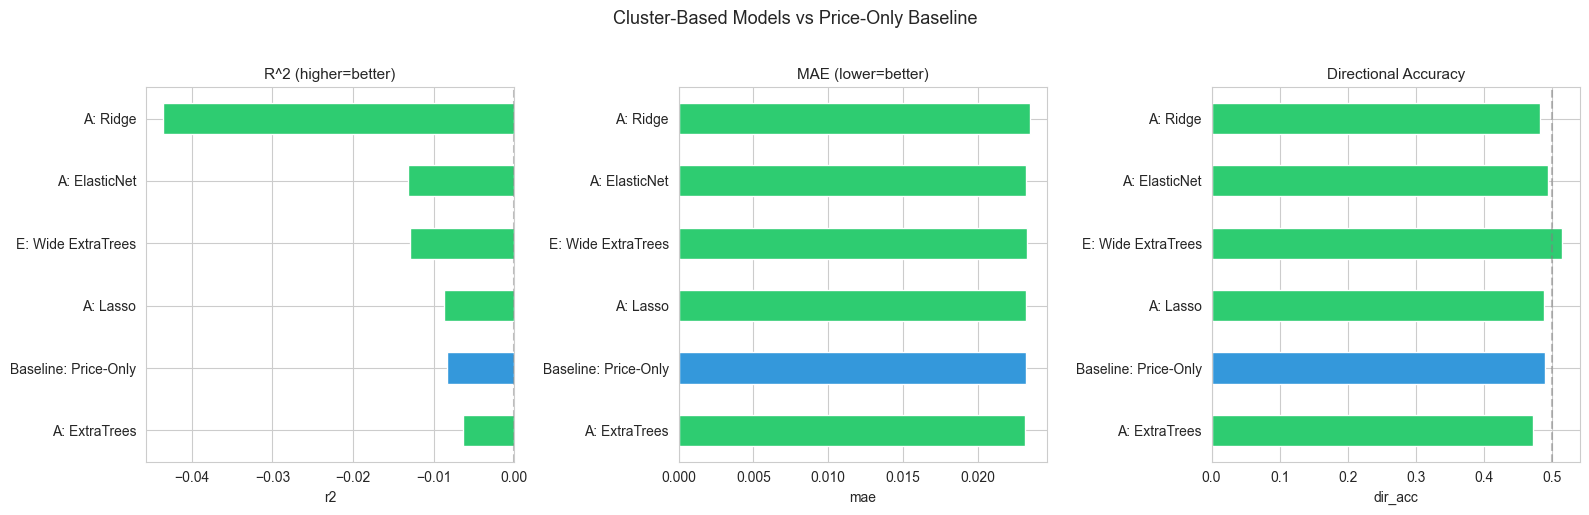

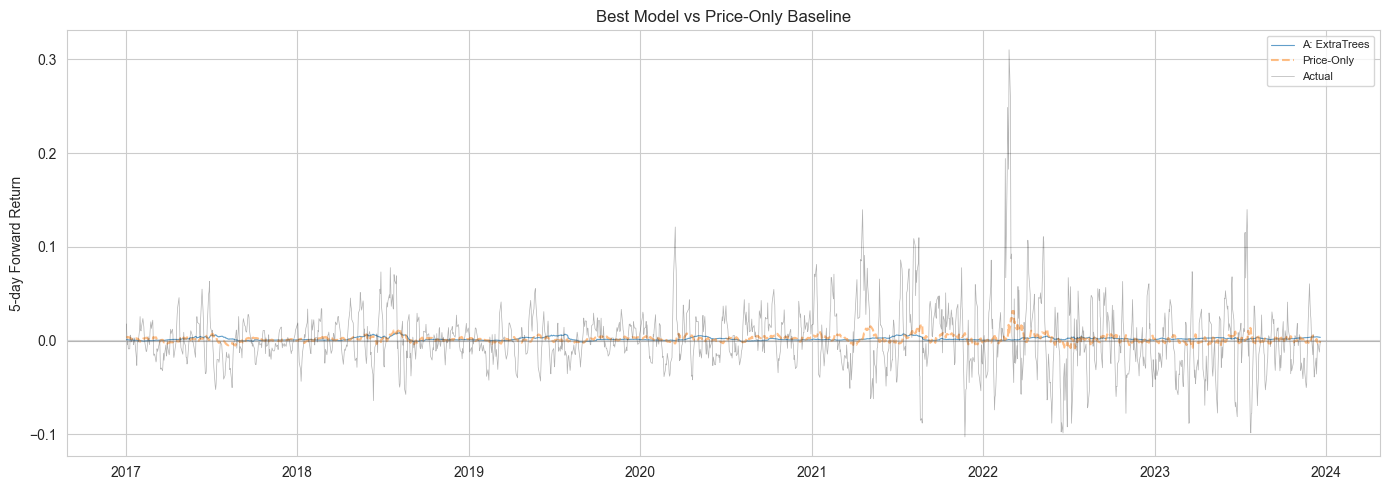

In [38]:
# ============================================================
# Comparison visualisation
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, title in zip(
    axes, ['r2', 'mae', 'dir_acc'],
    ['R^2 (higher=better)', 'MAE (lower=better)', 'Directional Accuracy']
):
    vals = lb_df[metric]
    colors = ['#2ecc71' if 'Baseline' not in n else '#3498db' for n in vals.index]
    vals.plot.barh(ax=ax, color=colors)
    if metric == 'r2':
        ax.axvline(x=0, color='grey', linestyle='--', alpha=0.5)
    elif metric == 'dir_acc':
        ax.axvline(x=0.5, color='grey', linestyle='--', alpha=0.5)
    ax.set_xlabel(metric)
    ax.set_title(title, fontsize=11)

plt.suptitle('Cluster-Based Models vs Price-Only Baseline', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Time series of best model vs baseline ---
fig, ax = plt.subplots(figsize=(14, 5))
best_name = lb_df.index[0]

# Find predictions for best model
for name in [best_name]:
    if name in approach_a_results:
        preds = approach_a_results[name]['predictions']
    elif name == 'B: Lasso Stack' and approach_b_result:
        preds = approach_b_result['predictions']
    elif name == 'C: PCA + Ridge' and approach_c_result:
        preds = approach_c_result['predictions']
    else:
        continue
    ax.plot(preds['Date'], preds['y_pred'], label=name, alpha=0.7, linewidth=0.8)

if baseline_result:
    bp = baseline_result['predictions']
    ax.plot(bp['Date'], bp['y_pred'], label='Price-Only', alpha=0.5, linestyle='--')
    ax.plot(bp['Date'], bp['Fwd_Return'], label='Actual', color='black', alpha=0.3, linewidth=0.5)

ax.axhline(y=0, color='grey', alpha=0.3)
ax.set_ylabel('5-day Forward Return')
ax.set_title('Best Model vs Price-Only Baseline')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Per-cluster performance breakdown (Approach A: Ridge)
# ============================================================
if 'C: PCA + ExtraTrees' in approach_a_results:
    print("\nPer-cluster performance (Ridge):")
    for c, metrics in approach_a_results['C: PCA + ExtraTrees']['per_cluster'].items():
        n_members = len(region_members.get(c, []))
        countries = {}
        for r in region_members.get(c, []):
            cc = r[:2]
            countries[cc] = countries.get(cc, 0) + 1
        country_str = ', '.join(f'{cc}:{n}' for cc, n in sorted(countries.items()))
        print(f"  Cluster {c} ({n_members} regions: {country_str}): "
              f"R2={metrics['r2']:.4f}, Dir={metrics['dir_acc']:.4f}")

---
## 7. Tail-Event Target


In [85]:
# ============================================================
# SECTION 7: TAIL-EVENT TARGET — REGRESSION ON EXTREME MOVES
# ============================================================
 
# --- 7.0 Target construction ---
LOOKBACK = 126
K_THRESHOLD = 2
 
futures_f = futures.dropna(subset=['Price']).copy().sort_values('Date').reset_index(drop=True)
futures_f['ret'] = futures_f['Price'].pct_change()
futures_f['roll_mu'] = futures_f['ret'].rolling(LOOKBACK).mean()
futures_f['roll_sigma'] = futures_f['ret'].rolling(LOOKBACK).std()
futures_f['z_score'] = (futures_f['ret'] - futures_f['roll_mu']) / futures_f['roll_sigma']
 
# y_tail_t = today's return if today is a tail event, else 0
futures_f['y_tail'] = np.where(futures_f['z_score'].abs() >= K_THRESHOLD, futures_f['ret'], 0.0)
 
# TARGET: tomorrow's tail return (shift -1 = look one day forward)
futures_f['y_tail_fwd'] = futures_f['y_tail'].shift(-1)
futures_f['is_tail_fwd'] = (futures_f['y_tail_fwd'] != 0).astype(int)
 
# Drop warm-up (first LOOKBACK rows where rolling stats are NaN) and last row (no target)
futures_f = futures_f.dropna(subset=['roll_sigma', 'y_tail_fwd']).copy()
 
# --- 7.0b Price-based features (all known at time t) ---
futures_f['ret_5d'] = futures_f['Price'].pct_change(5)
futures_f['ret_20d'] = futures_f['Price'].pct_change(20)
futures_f['vol_ratio'] = futures_f['Price'].rolling(5).std() / futures_f['Price'].rolling(60).std()
futures_f['z_abs'] = futures_f['z_score'].abs()
futures_f['z_abs_5d_max'] = futures_f['z_abs'].rolling(5).max()
futures_f['tail_freq_20d'] = futures_f['y_tail'].ne(0).rolling(20).sum()
futures_f['roll_sigma_chg'] = futures_f['roll_sigma'].pct_change(5)
 
base_cols = [
    'ret_5d', 'ret_20d', 'vol_ratio',
    'z_abs', 'z_abs_5d_max', 'tail_freq_20d',
    'roll_sigma', 'roll_sigma_chg', 'roll_mu'
]
 
# --- 7.0c Merge CY-Bench cluster features ---

# Step 1: concat all region dfs at once (not sequential merge)
cluster_parts = []
for c_id in sorted(all_region_dfs.keys()):
    cdf = all_region_dfs[c_id].copy()
    cdf = cdf.rename(columns={x: f'C{c_id}_{x}' for x in cdf.columns if x != 'date'})
    cdf = cdf.set_index('date')
    cluster_parts.append(cdf)

# One concat instead of N merges — orders of magnitude faster
all_clusters = pd.concat(cluster_parts, axis=1)
all_clusters = all_clusters.sort_index().ffill()
all_clusters = all_clusters.reset_index().rename(columns={'date': 'Date'})
# Ensure Date is datetime (concat can sometimes lose dtype)
all_clusters['Date'] = pd.to_datetime(all_clusters['Date'])

# Step 2: single merge_asof
wide_ag = futures_f[['Date', 'y_tail_fwd', 'is_tail_fwd'] + base_cols].copy()
wide_ag = wide_ag.sort_values('Date').reset_index(drop=True)
all_clusters = all_clusters.sort_values('Date').reset_index(drop=True)

wide_ag = pd.merge_asof(wide_ag, all_clusters, on='Date', direction='backward')

wide_ag = wide_ag.fillna(0)
wide_ag = wide_ag.dropna(subset=['y_tail_fwd'] + base_cols)
wide_ag['year'] = wide_ag['Date'].dt.year

ag_cols = [c for c in wide_ag.columns
           if c not in ['Date', 'y_tail_fwd', 'is_tail_fwd', 'year'] + base_cols]

n_tail = (wide_ag['y_tail_fwd'] != 0).sum()
print(f"Tail target: {len(wide_ag)} days, {n_tail} tail events ({n_tail/len(wide_ag)*100:.1f}%)")
print(f"Features: {len(base_cols)} price + {len(ag_cols)} ag = {len(base_cols) + len(ag_cols)} total")
 
n_tail = (wide_ag['y_tail_fwd'] != 0).sum()
print(f"Tail target: {len(wide_ag)} days, {n_tail} tail events ({n_tail/len(wide_ag)*100:.1f}%)")
print(f"Features: {len(base_cols)} price + {len(ag_cols)} ag = {len(base_cols) + len(ag_cols)} total")

Tail target: 5262 days, 294 tail events (5.6%)
Features: 9 price + 39132 ag = 39141 total
Tail target: 5262 days, 294 tail events (5.6%)
Features: 9 price + 39132 ag = 39141 total


In [112]:
# ============================================================
# 7.1 Walk-forward evaluation for tail target
#
# Key design choices:
#   - sample_weight: tail days get TAIL_WEIGHT × more loss
#     penalty, forcing the model away from the trivial
#     all-zero prediction (Section 11 discussion).
#   - Metrics: gate_auc (can the model distinguish tail from
#     normal days?), dir_tail (sign accuracy on tail days),
#     separation (ratio of mean |pred| on tail vs normal days
#     — measures whether predictions are larger when they
#     should be), plus standard RMSE/R²/DirAcc.
# ============================================================
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import (
    ExtraTreesRegressor, RandomForestRegressor, GradientBoostingRegressor
)
 
TAIL_WEIGHT = 1
 
def eval_tail(df, fcols, mc, mk, label):
    """
    Walk-forward evaluation for the tail-move target.
    Returns dict of metrics or None if insufficient data.
    """
    preds, aucs, yearly = [], [], []
 
    for ty in range(test_start_year, test_end_year + 1):
        tr = df[df['year'] < ty]
        te = df[df['year'] == ty]
        if len(tr) < 300 or len(te) < 20:
            continue
 
        sc = StandardScaler()
        X_tr = sc.fit_transform(tr[fcols].values)
        X_te = sc.transform(te[fcols].values)
        y_tr = tr['y_tail_fwd'].values
        y_te = te['y_tail_fwd'].values
 
        # Sample weights: upweight tail days
        w = np.where(y_tr != 0, TAIL_WEIGHT, 1.0)
 
        m = mc(**mk)
        try:
            m.fit(X_tr, y_tr, sample_weight=w)
        except TypeError:
            m.fit(X_tr, y_tr)
 
        yp = m.predict(X_te)
 
        # Gate AUC: can |prediction| distinguish tail from normal?
        it = te['is_tail_fwd'].values
        if it.sum() > 0 and it.sum() < len(it):
            try:
                aucs.append(roc_auc_score(it, np.abs(yp)))
            except:
                pass
 
        # Yearly metrics
        mse_yr = mean_squared_error(y_te, yp)
        r2_yr = r2_score(y_te, yp) if np.var(y_te) > 0 else 0.0
        tail_mask = it == 1
        dir_yr = (np.mean(np.sign(yp[tail_mask]) == np.sign(y_te[tail_mask]))
                  if tail_mask.sum() > 5 else np.nan)
        yearly.append({'year': ty, 'rmse': np.sqrt(mse_yr), 'r2': r2_yr,
                       'dir_tail': dir_yr, 'n_tail': int(tail_mask.sum())})
 
        pdf = te[['Date', 'y_tail_fwd', 'is_tail_fwd']].copy()
        pdf['y_pred'] = yp
        preds.append(pdf)
 
    if not preds:
        return None
 
    pr = pd.concat(preds, ignore_index=True)
    tm = pr['is_tail_fwd'] == 1
    y_all = pr['y_tail_fwd'].values
    p_all = pr['y_pred'].values
 
    # --- Aggregate metrics ---
    overall_mse = mean_squared_error(y_all, p_all)
    r = {
        'label': label,
        'rmse': np.sqrt(overall_mse),
        'r2': r2_score(y_all, p_all) if np.var(y_all) > 0 else 0.0,
        'dir_acc': np.mean(np.sign(p_all) == np.sign(y_all)),
        'gate_auc': np.mean(aucs) if aucs else np.nan,
        'n_tail': int(tm.sum()),
    }
 
    # Directional accuracy on tail days only
    if tm.sum() > 5:
        r['dir_tail'] = np.mean(
            np.sign(pr.loc[tm, 'y_pred'].values) == np.sign(pr.loc[tm, 'y_tail_fwd'].values)
        )
    else:
        r['dir_tail'] = np.nan
 
    # Separation: mean |pred| on tail days / mean |pred| on normal days
    # High separation = model predicts larger magnitudes when it should
    pt = pr.loc[tm, 'y_pred'].abs().mean() if tm.sum() > 0 else 0
    pn = pr.loc[~tm, 'y_pred'].abs().mean()
    r['separation'] = pt / pn if pn > 0 else 0
 
    # Magnitude ratio: std(pred on tail) / std(actual on tail)
    # Close to 1.0 = good, << 1 = predictions too smooth
    if tm.sum() > 5:
        r['mag_ratio'] = np.std(p_all[tm.values]) / np.std(y_all[tm.values]) if np.std(y_all[tm.values]) > 0 else 0
    else:
        r['mag_ratio'] = np.nan
 
    r['predictions'] = pr
    r['yearly'] = pd.DataFrame(yearly)
    return r
 
 
print(f"eval_tail() defined. TAIL_WEIGHT={TAIL_WEIGHT}")
print(f"Test period: {test_start_year}–{test_end_year}")

eval_tail() defined. TAIL_WEIGHT=1
Test period: 2017–2023


In [113]:
# ============================================================
# 7.2 Run all models
# ============================================================
 
MODELS_TAIL = {
    'Ridge':  (Ridge, {'alpha': 1.0}),
    'Lasso':  (Lasso, {'alpha': 0.001, 'max_iter': 10000}),
    'ET':     (ExtraTreesRegressor, {
                  'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 20,
                  'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1}),
    'RF':     (RandomForestRegressor, {
                  'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 20,
                  'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1}),
#    'GBR':    (GradientBoostingRegressor, {
#                  'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01,
#                  'subsample': 0.8, 'random_state': 42}),
}
 
print("=" * 70)
print("TAIL-MOVE REGRESSION: CY-Bench AG Features")
print("=" * 70)
 
tail_results = {}
 
for mn, (mc, mk) in MODELS_TAIL.items():
    r = eval_tail(wide_ag, ag_cols, mc, mk, 'AG')
    if r:
        tail_results[mn] = r
        print(f" {mn:5}: RMSE={r['rmse']:.6f}  "
              f"Dir(tail)={r['dir_tail']:.3f}  AUC={r['gate_auc']:.3f}  "
              f"Sep={r['separation']:.2f}x  MagRatio={r['mag_ratio']:.2f}")
 
# --- Price-only baseline (no ag features) ---
print("\n--- Price-Only Baseline ---")
for mn, (mc, mk) in MODELS_TAIL.items():
    r = eval_tail(wide_ag, base_cols, mc, mk, 'Price-Only')
    if r:
        tail_results[f'{mn} (price-only)'] = r
        print(f" {mn:5}: RMSE={r['rmse']:.6f}  "
              f"Dir(tail)={r['dir_tail']:.3f}  AUC={r['gate_auc']:.3f}  "
              f"Sep={r['separation']:.2f}x  MagRatio={r['mag_ratio']:.2f}")

TAIL-MOVE REGRESSION: CY-Bench AG Features
 Ridge: RMSE=0.051299  Dir(tail)=0.523  AUC=0.533  Sep=1.06x  MagRatio=1.44
 Lasso: RMSE=0.009125  Dir(tail)=0.617  AUC=0.500  Sep=1.00x  MagRatio=0.00
 ET   : RMSE=0.009159  Dir(tail)=0.570  AUC=0.595  Sep=1.54x  MagRatio=0.03
 RF   : RMSE=0.009182  Dir(tail)=0.617  AUC=0.538  Sep=1.43x  MagRatio=0.04

--- Price-Only Baseline ---
 Ridge: RMSE=0.009129  Dir(tail)=0.598  AUC=0.577  Sep=1.42x  MagRatio=0.03
 Lasso: RMSE=0.009125  Dir(tail)=0.617  AUC=0.500  Sep=1.00x  MagRatio=0.00
 ET   : RMSE=0.009116  Dir(tail)=0.570  AUC=0.628  Sep=1.52x  MagRatio=0.01
 RF   : RMSE=0.009154  Dir(tail)=0.589  AUC=0.582  Sep=1.68x  MagRatio=0.03


In [114]:
# ============================================================
# 7.3 Leaderboard
# ============================================================
print("\n" + "=" * 70)
print("TAIL-MOVE LEADERBOARD")
print("=" * 70)
 
lb_rows = []
for name, r in tail_results.items():
    lb_rows.append({
        'model': name,
        'features': r['label'],
        'r2': r['r2'],
        'rmse': r['rmse'],
        'dir_tail': r['dir_tail'],
        'gate_auc': r['gate_auc'],
        'separation': r['separation'],
        'mag_ratio': r['mag_ratio'],
        'n_tail': r['n_tail'],
    })
 
tail_lb = pd.DataFrame(lb_rows).set_index('model')
tail_lb = tail_lb.sort_values('gate_auc', ascending=False)
print(tail_lb.to_string(float_format='%.4f'))
 
best_tail = tail_lb.index[0]
print(f"\nBest gate_auc: {best_tail}")


TAIL-MOVE LEADERBOARD
                      features       r2   rmse  dir_tail  gate_auc  separation  mag_ratio  n_tail
model                                                                                            
ET (price-only)     Price-Only   0.0018 0.0091    0.5701    0.6275      1.5185     0.0129     107
ET                          AG  -0.0077 0.0092    0.5701    0.5955      1.5411     0.0282     107
RF (price-only)     Price-Only  -0.0065 0.0092    0.5888    0.5818      1.6765     0.0306     107
Ridge (price-only)  Price-Only  -0.0011 0.0091    0.5981    0.5770      1.4236     0.0288     107
RF                          AG  -0.0127 0.0092    0.6168    0.5384      1.4327     0.0370     107
Ridge                       AG -30.6110 0.0513    0.5234    0.5330      1.0637     1.4390     107
Lasso                       AG  -0.0002 0.0091    0.6168    0.5000      0.9971     0.0002     107
Lasso (price-only)  Price-Only  -0.0002 0.0091    0.6168    0.5000      0.9971     0.0002     1

In [115]:
# ============================================================
# 7.4 Diebold-Mariano tests: AG models vs their price-only counterpart
# ============================================================
from scipy import stats
 
def diebold_mariano_test(actual, pred_1, pred_2, h=1, loss='mse'):
    """
    Diebold-Mariano (1995) test with Harvey-Leybourne-Newbold (1997)
    small-sample correction.
    
    H0: equal predictive accuracy. Positive DM stat = model 1 better.
    """
    e1 = actual - np.asarray(pred_1)
    e2 = actual - np.asarray(pred_2)
    d = e2**2 - e1**2 if loss == 'mse' else np.abs(e2) - np.abs(e1)
    T = len(d)
    d_bar = np.mean(d)
    max_lag = max(h - 1, 1)
    d_dm = d - d_bar
    gamma = np.array([np.mean(d_dm[:T-k] * d_dm[k:]) for k in range(max_lag + 1)])
    V = gamma[0] + 2 * sum((1 - k/(max_lag+1)) * gamma[k] for k in range(1, max_lag+1))
    if V <= 0:
        return {'dm_stat': 0., 'p_value': 1., 'conclusion': 'Degenerate'}
    dm = d_bar / np.sqrt(V / T)
    hln = np.sqrt((T + 1 - 2*h + h*(h-1)/T) / T)
    dm_c = dm * hln
    pv = 2 * stats.t.sf(np.abs(dm_c), df=T-1)
    sig = '***' if pv < 0.01 else '**' if pv < 0.05 else '*' if pv < 0.10 else ''
    who = 'AG better' if d_bar > 0 else 'Price-only better'
    return {'dm_stat': dm_c, 'p_value': pv,
            'conclusion': f"{who} (DM={dm_c:.3f}, p={pv:.4f}{sig})"}
 
 
print("\n" + "=" * 70)
print("DIEBOLD-MARIANO TESTS: AG vs PRICE-ONLY (h=1, MSE loss)")
print("=" * 70)
 
for mn in MODELS_TAIL.keys():
    ag_key = mn
    po_key = f'{mn} (price-only)'
    if ag_key not in tail_results or po_key not in tail_results:
        continue
    pr_ag = tail_results[ag_key]['predictions']
    pr_po = tail_results[po_key]['predictions']
    merged = pr_ag[['Date', 'y_tail_fwd', 'y_pred']].merge(
        pr_po[['Date', 'y_pred']], on='Date', suffixes=('_ag', '_po')
    )
    dm = diebold_mariano_test(
        merged['y_tail_fwd'].values,
        merged['y_pred_ag'].values,
        merged['y_pred_po'].values,
        h=1, loss='mse'
    )
    print(f"  {mn:8s} → {dm['conclusion']}")
 
print("\n  *** p<0.01, ** p<0.05, * p<0.10")


DIEBOLD-MARIANO TESTS: AG vs PRICE-ONLY (h=1, MSE loss)
  Ridge    → Price-only better (DM=-16.623, p=0.0000***)
  Lasso    → Degenerate
  ET       → Price-only better (DM=-1.897, p=0.0581*)
  RF       → Price-only better (DM=-0.661, p=0.5086)

  *** p<0.01, ** p<0.05, * p<0.10


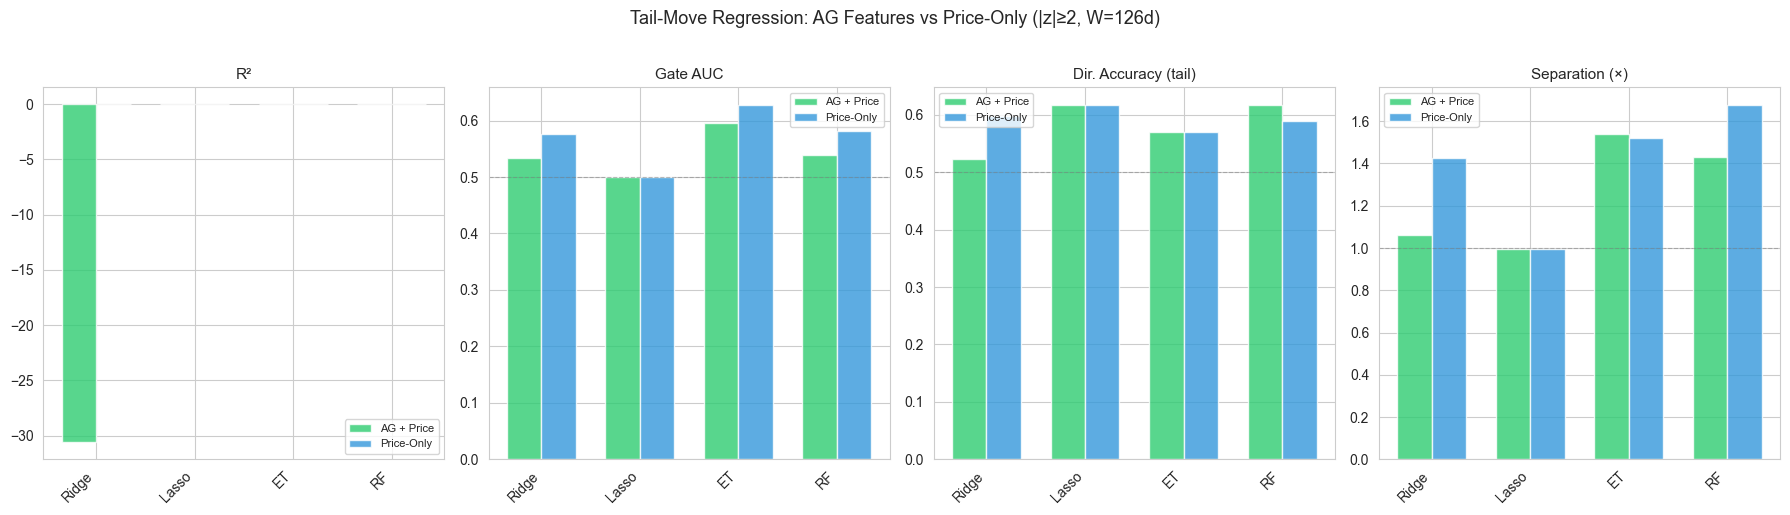

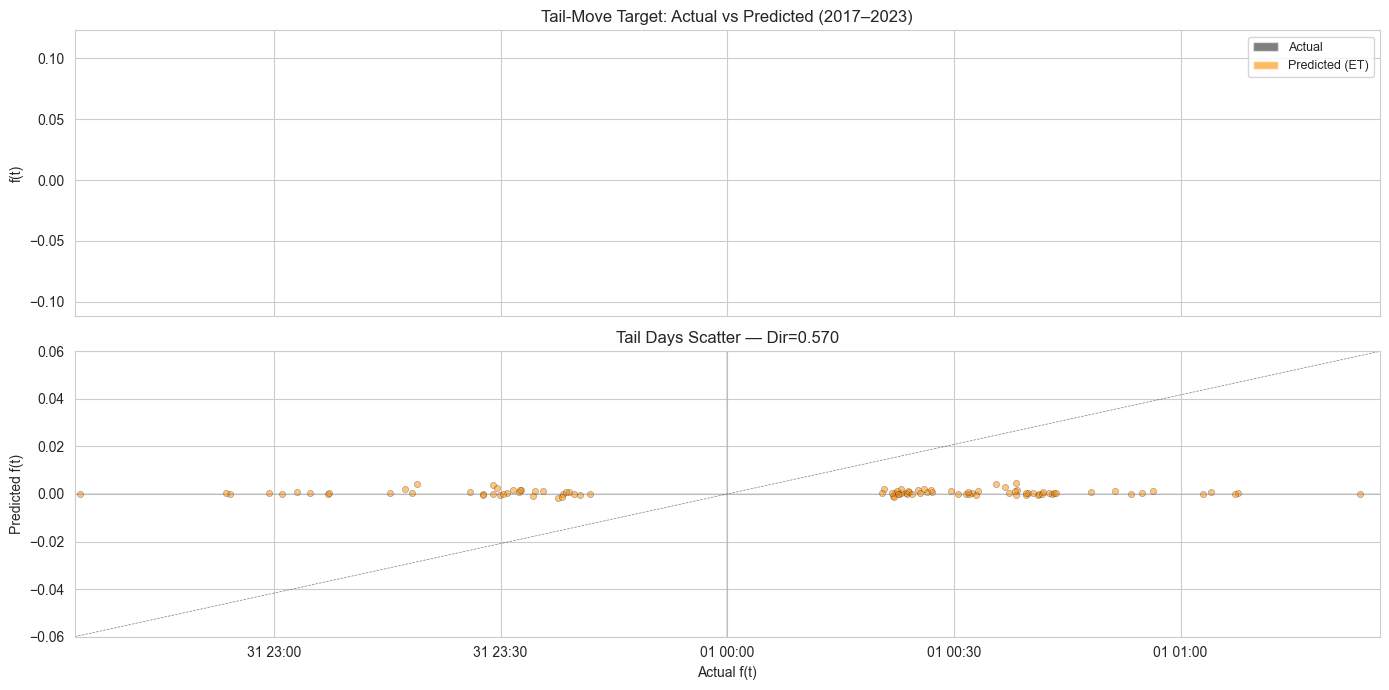

In [116]:
# ============================================================
# 7.5 Visualisation
# ============================================================
 
# --- Bar chart comparison ---
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics_to_plot = [
    ('r2', 'R²', None),
    ('gate_auc', 'Gate AUC', 0.5),
    ('dir_tail', 'Dir. Accuracy (tail)', 0.5),
    ('separation', 'Separation (×)', 1.0),
]
 
# Split into AG and price-only for side-by-side
ag_models = [n for n in tail_lb.index if 'price-only' not in n]
po_models = [n for n in tail_lb.index if 'price-only' in n]
 
for ax, (metric, title, ref_line) in zip(axes, metrics_to_plot):
    x = np.arange(len(MODELS_TAIL))
    w = 0.35
    ag_vals = [tail_lb.loc[mn, metric] if mn in tail_lb.index else 0 for mn in MODELS_TAIL.keys()]
    po_vals = [tail_lb.loc[f'{mn} (price-only)', metric]
               if f'{mn} (price-only)' in tail_lb.index else 0 for mn in MODELS_TAIL.keys()]
    ax.bar(x - w/2, ag_vals, w, label='AG + Price', color='#2ecc71', alpha=0.8)
    ax.bar(x + w/2, po_vals, w, label='Price-Only', color='#3498db', alpha=0.8)
    if ref_line is not None:
        ax.axhline(ref_line, color='grey', ls='--', lw=0.8, alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(MODELS_TAIL.keys(), rotation=45, ha='right')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)
 
plt.suptitle(f'Tail-Move Regression: AG Features vs Price-Only (|z|≥{K_THRESHOLD}, W={LOOKBACK}d)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
 
# --- Predictions time series for best model ---
best_name = ag_models[0] if ag_models else list(tail_results.keys())[0]
best_pr = tail_results[best_name]['predictions']
 
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
 
ax = axes[0]
ax.bar(best_pr['Date'], best_pr['y_tail_fwd'], width=2, color='black', alpha=0.5, label='Actual')
ax.bar(best_pr['Date'], best_pr['y_pred'], width=2, color='darkorange', alpha=0.6, label=f'Predicted ({best_name})')
ax.set_ylabel('f(t)')
ax.set_title(f'Tail-Move Target: Actual vs Predicted ({test_start_year}–{test_end_year})')
ax.legend(fontsize=9)
 
ax = axes[1]
tail_mask = best_pr['is_tail_fwd'] == 1
ax.scatter(best_pr.loc[tail_mask, 'y_tail_fwd'], best_pr.loc[tail_mask, 'y_pred'],
           alpha=0.5, s=20, color='darkorange', edgecolors='black', linewidths=0.3)
lims = [-0.06, 0.06]
ax.plot(lims, lims, 'k--', lw=0.5, alpha=0.5)
ax.axhline(0, color='grey', lw=0.3); ax.axvline(0, color='grey', lw=0.3)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Actual f(t)'); ax.set_ylabel('Predicted f(t)')
ax.set_title(f'Tail Days Scatter — Dir={tail_results[best_name]["dir_tail"]:.3f}')
 
plt.tight_layout()
plt.show()

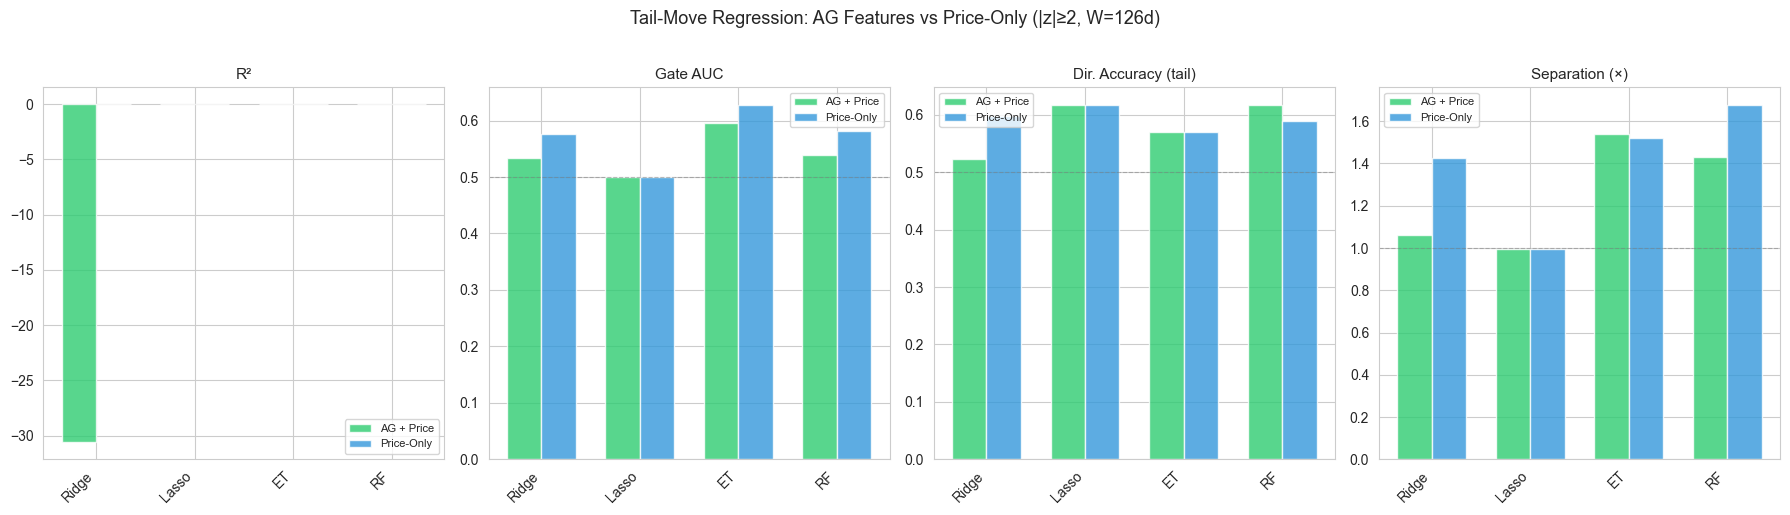

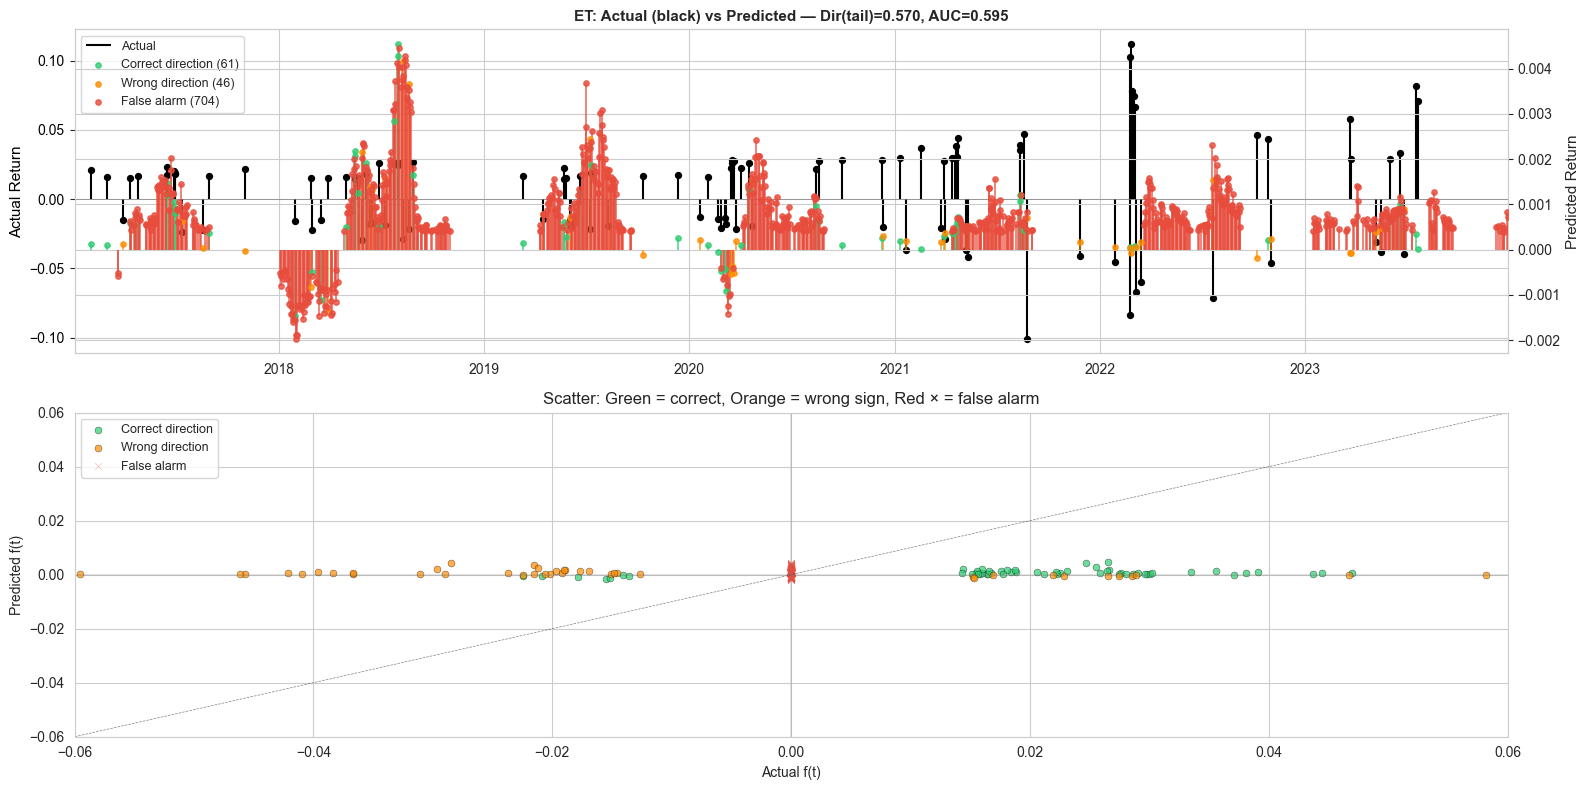

In [117]:
# ============================================================
# 7.5 Visualisation
# ============================================================

# --- Bar chart comparison ---
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics_to_plot = [
    ('r2', 'R²', None),
    ('gate_auc', 'Gate AUC', 0.5),
    ('dir_tail', 'Dir. Accuracy (tail)', 0.5),
    ('separation', 'Separation (×)', 1.0),
]

ag_models = [n for n in tail_lb.index if 'price-only' not in n]
po_models = [n for n in tail_lb.index if 'price-only' in n]

for ax, (metric, title, ref_line) in zip(axes, metrics_to_plot):
    x = np.arange(len(MODELS_TAIL))
    w = 0.35
    ag_vals = [tail_lb.loc[mn, metric] if mn in tail_lb.index else 0 for mn in MODELS_TAIL.keys()]
    po_vals = [tail_lb.loc[f'{mn} (price-only)', metric]
               if f'{mn} (price-only)' in tail_lb.index else 0 for mn in MODELS_TAIL.keys()]
    ax.bar(x - w/2, ag_vals, w, label='AG + Price', color='#2ecc71', alpha=0.8)
    ax.bar(x + w/2, po_vals, w, label='Price-Only', color='#3498db', alpha=0.8)
    if ref_line is not None:
        ax.axhline(ref_line, color='grey', ls='--', lw=0.8, alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(MODELS_TAIL.keys(), rotation=45, ha='right')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle(f'Tail-Move Regression: AG Features vs Price-Only (|z|≥{K_THRESHOLD}, W={LOOKBACK}d)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


# --- Colour-coded spike plot for best model ---
best_name = ag_models[0] if ag_models else list(tail_results.keys())[0]
best_pr = tail_results[best_name]['predictions']

dates = best_pr['Date'].values
actual = best_pr['y_tail_fwd'].values
predicted = best_pr['y_pred'].values
is_tail = best_pr['is_tail_fwd'].values == 1

# Classify predictions
correct_dir = is_tail & (np.sign(predicted) == np.sign(actual))
wrong_dir   = is_tail & (np.sign(predicted) != np.sign(actual))

# False alarms: not a tail day but model predicted a spike
# Use mean |pred| on tail days as threshold — anything above this on a normal day is a false alarm
tail_pred_mean = np.abs(predicted[is_tail]).mean() if is_tail.sum() > 0 else 0
false_alarm = (~is_tail) & (np.abs(predicted) > tail_pred_mean * 0.5)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

# --- Panel 1: Dual-axis spike plot ---
ax1 = axes[0]

# Left axis: actual (black)
ax1.vlines(dates[is_tail], 0, actual[is_tail], color='black', linewidth=1.5, label='Actual')
ax1.scatter(dates[is_tail], actual[is_tail], s=18, color='black', zorder=5)
ax1.axhline(0, color='grey', lw=0.5)
ax1.set_ylabel('Actual Return', color='black', fontsize=11)
ax1.tick_params(axis='y', labelcolor='black')

# Right axis: predictions coloured by outcome
ax2 = ax1.twinx()

for mask, color, label in [
    (correct_dir, '#2ecc71',   f'Correct direction ({correct_dir.sum()})'),
    (wrong_dir,   'darkorange', f'Wrong direction ({wrong_dir.sum()})'),
    (false_alarm, '#e74c3c',   f'False alarm ({false_alarm.sum()})'),
]:
    if mask.sum() > 0:
        ax2.vlines(dates[mask], 0, predicted[mask], color=color, linewidth=1.2, alpha=0.8)
        ax2.scatter(dates[mask], predicted[mask], s=15, color=color, zorder=5, alpha=0.8, label=label)

ax2.set_ylabel('Predicted Return', fontsize=11)
ax1.set_xlim(dates[0], dates[-1])

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=9)

ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.set_title(f'{best_name}: Actual (black) vs Predicted — '
              f'Dir(tail)={tail_results[best_name]["dir_tail"]:.3f}, '
              f'AUC={tail_results[best_name]["gate_auc"]:.3f}',
              fontsize=11, fontweight='bold')

# --- Panel 2: Scatter, coloured by outcome ---
ax = axes[1]

for mask, color, label in [
    (correct_dir, '#2ecc71',    'Correct direction'),
    (wrong_dir,   'darkorange', 'Wrong direction'),
]:
    if mask.sum() > 0:
        ax.scatter(actual[mask], predicted[mask], s=25, color=color,
                   edgecolors='black', linewidths=0.3, alpha=0.7, label=label)

# False alarms on scatter: actual ≈ 0, predicted ≠ 0
if false_alarm.sum() > 0:
    ax.scatter(actual[false_alarm], predicted[false_alarm], s=25, color='#e74c3c',
               edgecolors='black', linewidths=0.3, alpha=0.5, label='False alarm', marker='x')

lims = [-0.06, 0.06]
ax.plot(lims, lims, 'k--', lw=0.5, alpha=0.5)
ax.axhline(0, color='grey', lw=0.3)
ax.axvline(0, color='grey', lw=0.3)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Actual f(t)')
ax.set_ylabel('Predicted f(t)')
ax.set_title('Scatter: Green = correct, Orange = wrong sign, Red × = false alarm')
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

---
## 8. Hurdle Model - the two stage approach

In [121]:
# ============================================================
# 8. Hurdle (Two-Stage) Model
#
# Stage 1 — CLASSIFIER (ExtraTrees): "will tomorrow be a tail day?"
#   Trained on all days, predicts P(tail) ∈ [0, 1].
#   Uses class_weight='balanced' to handle the ~75/25 imbalance
#   (equivalent to upweighting the minority class).
#
# Stage 2 — REGRESSOR (ExtraTrees): "given a tail day, what's the return?"
#   Trained ONLY on tail days — never sees zeros.
#   Predicts signed magnitude of the tail-day return.
#
# Final prediction = P(tail) × predicted_magnitude
#   - Normal day: P(tail) ≈ 0.1 → prediction shrunk towards 0
#   - Tail day:   P(tail) ≈ 0.8 → prediction close to full magnitude
#
# This decomposition lets each stage focus on what it's good at:
#   the classifier learns WHEN, the regressor learns HOW MUCH.
# ============================================================
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor
from sklearn.metrics import roc_auc_score

h_df = wide_ag
h_feats = ag_cols

hurdle_preds = []
hurdle_aucs = []

print("=" * 60)
print("HURDLE MODEL: Classifier (gate) + Regressor (magnitude)")
print("=" * 60)

for ty in range(test_start_year, test_end_year + 1):
    tr = h_df[h_df['year'] < ty]
    te = h_df[h_df['year'] == ty]
    if len(tr) < 300 or len(te) < 20:
        continue

    sc = StandardScaler()
    X_tr = sc.fit_transform(tr[h_feats].values)
    X_te = sc.transform(te[h_feats].values)

    # --- Stage 1: Gate classifier ---
    # Predicts P(tomorrow is a tail day)
    gate = ExtraTreesClassifier(
        n_estimators=1000, max_depth=8, min_samples_leaf=50, max_features='sqrt',
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    gate.fit(X_tr, tr['is_tail_fwd'].values)
    p_tail = gate.predict_proba(X_te)[:, 1]  # probability of tail

    # Gate AUC for this year
    it = te['is_tail_fwd'].values
    if it.sum() > 0 and it.sum() < len(it):
        auc = roc_auc_score(it, p_tail)
        hurdle_aucs.append(auc)
    else:
        auc = np.nan

    # --- Stage 2: Magnitude regressor (tail-only training) ---
    tail_tr = tr[tr['is_tail_fwd'] == 1]

    if len(tail_tr) >= 20:
        mag = ExtraTreesRegressor(
            n_estimators=1000, max_depth=8, min_samples_leaf=50, max_features='sqrt',
            random_state=42, n_jobs=-1
        )
        mag.fit(sc.transform(tail_tr[h_feats].values), tail_tr['y_tail_fwd'].values)
        mag_pred = mag.predict(X_te)
    else:
        # Fallback: predict the mean tail return if too few tail samples
        fallback = tail_tr['y_tail_fwd'].mean() if len(tail_tr) > 0 else 0
        mag_pred = np.full(len(te), fallback)

    # --- Combined prediction: P(tail) × magnitude ---
    y_pred = p_tail * mag_pred

    n_tail_yr = it.sum()
    tail_mask_yr = it == 1
    dir_yr = (np.mean(np.sign(y_pred[tail_mask_yr]) == np.sign(te['y_tail_fwd'].values[tail_mask_yr]))
              if n_tail_yr > 5 else np.nan)

    print(f"  {ty}: Gate AUC={auc:.3f}, "
          f"tail days={n_tail_yr}, "
          f"Dir(tail)={dir_yr:.3f}, "
          f"mean P(tail)={p_tail.mean():.3f}")

    pdf = te[['Date', 'y_tail_fwd', 'is_tail_fwd']].copy()
    pdf['p_tail'] = p_tail
    pdf['mag_pred'] = mag_pred
    pdf['y_pred'] = y_pred
    hurdle_preds.append(pdf)

# --- Aggregate results ---
if hurdle_preds:
    hp = pd.concat(hurdle_preds, ignore_index=True)
    mean_auc = np.mean(hurdle_aucs) if hurdle_aucs else np.nan
    tm = hp['is_tail_fwd'] == 1
    y_all = hp['y_tail_fwd'].values
    p_all = hp['y_pred'].values

    dir_tail = (np.mean(np.sign(hp.loc[tm, 'y_pred'].values) == np.sign(hp.loc[tm, 'y_tail_fwd'].values))
                if tm.sum() > 5 else np.nan)

    # Separation
    pt = hp.loc[tm, 'y_pred'].abs().mean() if tm.sum() > 0 else 0
    pn = hp.loc[~tm, 'y_pred'].abs().mean()
    separation = pt / pn if pn > 0 else 0

    # Magnitude ratio on tail days
    mag_ratio = (np.std(p_all[tm.values]) / np.std(y_all[tm.values])
                 if tm.sum() > 5 and np.std(y_all[tm.values]) > 0 else np.nan)

    overall_mse = mean_squared_error(y_all, p_all)

    # --- Gate diagnostics (using p_tail threshold = 0.5) ---
    DIAG_THRESHOLD = 0.5
    gate_open = hp['p_tail'].values >= DIAG_THRESHOLD
    is_tail_arr = tm.values

    caught       = (gate_open & is_tail_arr).sum()
    missed       = (~gate_open & is_tail_arr).sum()
    false_alarms = (gate_open & ~is_tail_arr).sum()
    correct_zero = (~gate_open & ~is_tail_arr).sum()

    gate_precision = caught / (caught + false_alarms) if (caught + false_alarms) > 0 else 0
    gate_recall    = caught / (caught + missed) if (caught + missed) > 0 else 0
    gate_f1        = (2 * gate_precision * gate_recall / (gate_precision + gate_recall)
                      if (gate_precision + gate_recall) > 0 else 0)

    print(f"\n{'='*60}")
    print(f"HURDLE MODEL SUMMARY")
    print(f"{'='*60}")
    print(f"  Gate AUC:       {mean_auc:.3f}")
    print(f"  Dir(tail):      {dir_tail:.3f}")
    print(f"  Separation:     {separation:.2f}×")
    print(f"  MagRatio:       {mag_ratio:.2f}")
    print(f"  RMSE:           {np.sqrt(overall_mse):.6f}")
    print(f"  R²:             {r2_score(y_all, p_all):.4f}")
    print(f"  Tail days:      {tm.sum()} / {len(hp)}")
    print(f"\n  --- Gate Analysis (threshold={DIAG_THRESHOLD}) ---")
    print(f"  Caught tails:   {caught}/{caught+missed} ({gate_recall:.1%} recall)")
    print(f"  False alarms:   {false_alarms}")
    print(f"  Correct zeros:  {correct_zero}")
    print(f"  Precision:      {gate_precision:.3f}")
    print(f"  Recall:         {gate_recall:.3f}")
    print(f"  F1:             {gate_f1:.3f}")

    hurdle_result = {
        'predictions': hp,
        'overall': {
            'gate_auc': mean_auc, 'dir_tail': dir_tail,
            'separation': separation, 'mag_ratio': mag_ratio,
            'rmse': np.sqrt(overall_mse), 'r2': r2_score(y_all, p_all),
            'n_tail': int(tm.sum()), 'caught': int(caught),
            'false_alarms': int(false_alarms),
            'gate_precision': gate_precision, 'gate_recall': gate_recall,
            'gate_f1': gate_f1,
        }
    }

HURDLE MODEL: Classifier (gate) + Regressor (magnitude)
  2017: Gate AUC=0.632, tail days=14, Dir(tail)=0.571, mean P(tail)=0.337
  2018: Gate AUC=0.776, tail days=21, Dir(tail)=0.619, mean P(tail)=0.402
  2019: Gate AUC=0.633, tail days=13, Dir(tail)=0.462, mean P(tail)=0.335
  2020: Gate AUC=0.543, tail days=19, Dir(tail)=0.526, mean P(tail)=0.334
  2021: Gate AUC=0.576, tail days=18, Dir(tail)=0.611, mean P(tail)=0.363
  2022: Gate AUC=0.611, tail days=13, Dir(tail)=0.308, mean P(tail)=0.390
  2023: Gate AUC=0.797, tail days=9, Dir(tail)=0.444, mean P(tail)=0.372

HURDLE MODEL SUMMARY
  Gate AUC:       0.653
  Dir(tail):      0.523
  Separation:     1.35×
  MagRatio:       0.09
  RMSE:           0.009690
  R²:             -0.1278
  Tail days:      107 / 1791

  --- Gate Analysis (threshold=0.5) ---
  Caught tails:   33/107 (30.8% recall)
  False alarms:   358
  Correct zeros:  1326
  Precision:      0.084
  Recall:         0.308
  F1:             0.133


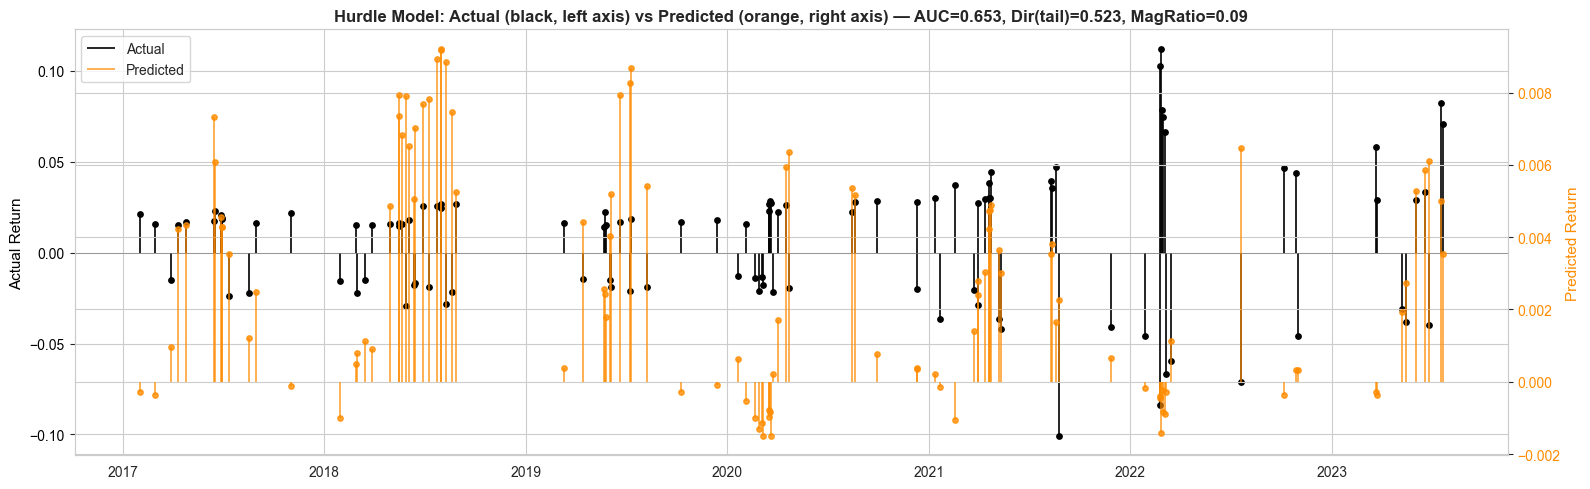

In [122]:
# ============================================================
# 8.1 Hurdle Model — Actual vs Predicted Spikes (shared plot, dual axes)
# ============================================================
fig, ax1 = plt.subplots(figsize=(16, 5))

dates = hp['Date']
actual = hp['y_tail_fwd'].values
predicted = hp['y_pred'].values
is_tail = hp['is_tail_fwd'].values == 1

# Left axis: actual spikes (black)
ax1.vlines(dates[is_tail], 0, actual[is_tail], color='black', linewidth=1.2, label='Actual')
ax1.scatter(dates[is_tail], actual[is_tail], s=15, color='black', zorder=5)
ax1.axhline(0, color='grey', lw=0.5)
ax1.set_ylabel('Actual Return', color='black', fontsize=11)
ax1.tick_params(axis='y', labelcolor='black')

# Right axis: predicted spikes (orange)
ax2 = ax1.twinx()
ax2.vlines(dates[is_tail], 0, predicted[is_tail], color='darkorange', linewidth=1.2, alpha=0.8, label='Predicted')
ax2.scatter(dates[is_tail], predicted[is_tail], s=15, color='darkorange', zorder=5, alpha=0.8)
ax2.set_ylabel('Predicted Return', color='darkorange', fontsize=11)
ax2.tick_params(axis='y', labelcolor='darkorange')

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=10)

ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.set_title(f'Hurdle Model: Actual (black, left axis) vs Predicted (orange, right axis) — '
              f'AUC={mean_auc:.3f}, Dir(tail)={dir_tail:.3f}, MagRatio={mag_ratio:.2f}',
              fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

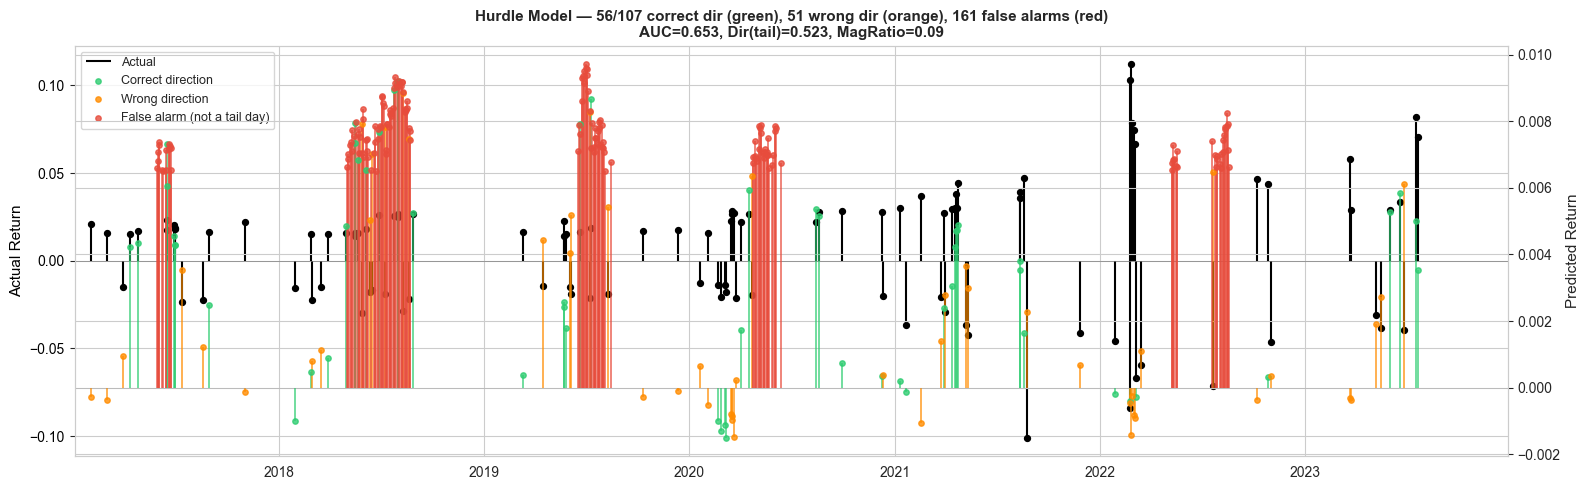

In [123]:
# ============================================================
# 8.1 Hurdle Model — Actual vs Predicted Spikes (colour-coded)
#
#   Black  = actual tail returns (left axis)
#   Green  = predicted on tail day, correct direction
#   Orange = predicted on tail day, wrong direction
#   Red    = predicted spike on a non-tail day (false alarm)
# ============================================================
fig, ax1 = plt.subplots(figsize=(16, 5))

dates = hp['Date'].values
actual = hp['y_tail_fwd'].values
predicted = hp['y_pred'].values
is_tail = hp['is_tail_fwd'].values == 1

# --- Left axis: actual spikes (always black) ---
ax1.vlines(dates[is_tail], 0, actual[is_tail], color='black', linewidth=1.5, label='Actual')
ax1.scatter(dates[is_tail], actual[is_tail], s=18, color='black', zorder=5)
ax1.axhline(0, color='grey', lw=0.5)
ax1.set_ylabel('Actual Return', color='black', fontsize=11)
ax1.tick_params(axis='y', labelcolor='black')

# --- Right axis: predicted spikes (colour-coded) ---
ax2 = ax1.twinx()

# Classify each prediction
correct_dir = is_tail & (np.sign(predicted) == np.sign(actual))   # green
wrong_dir   = is_tail & (np.sign(predicted) != np.sign(actual))   # orange

# False alarms: not a tail day but model predicted something notable
pred_threshold = np.percentile(np.abs(predicted), 90)  # top 10% of |predictions|
false_alarm = (~is_tail) & (np.abs(predicted) > pred_threshold)   # red

# Plot each category
for mask, color, label in [
    (correct_dir, '#2ecc71', 'Correct direction'),
    (wrong_dir,   'darkorange', 'Wrong direction'),
    (false_alarm, '#e74c3c', 'False alarm (not a tail day)'),
]:
    if mask.sum() > 0:
        ax2.vlines(dates[mask], 0, predicted[mask], color=color, linewidth=1.2, alpha=0.8)
        ax2.scatter(dates[mask], predicted[mask], s=15, color=color, zorder=5, alpha=0.8, label=label)

ax2.axhline(0, color='grey', lw=0.5, alpha=0.3)
ax2.set_ylabel('Predicted Return', fontsize=11)

# Align x-axis
ax1.set_xlim(dates[0], dates[-1])

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=9)

ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Counts for title
n_correct = correct_dir.sum()
n_wrong = wrong_dir.sum()
n_false = false_alarm.sum()
n_total_tail = is_tail.sum()

ax1.set_title(
    f'Hurdle Model — {n_correct}/{n_total_tail} correct dir (green), '
    f'{n_wrong} wrong dir (orange), {n_false} false alarms (red)\n'
    f'AUC={mean_auc:.3f}, Dir(tail)={dir_tail:.3f}, MagRatio={mag_ratio:.2f}',
    fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

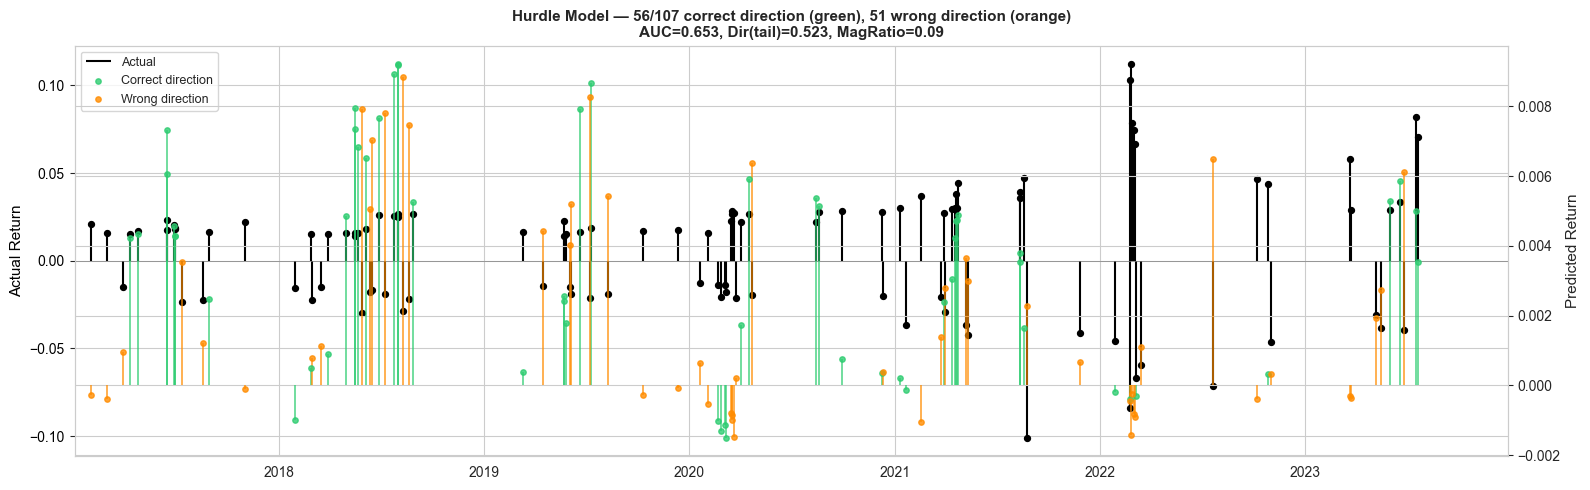

In [102]:
# ============================================================
# 8.1 Hurdle Model — Actual vs Predicted Spikes (colour-coded)
#
#   Black  = actual tail returns (left axis)
#   Green  = predicted, correct direction (right axis)
#   Orange = predicted, wrong direction (right axis)
# ============================================================
fig, ax1 = plt.subplots(figsize=(16, 5))

dates = hp['Date'].values
actual = hp['y_tail_fwd'].values
predicted = hp['y_pred'].values
is_tail = hp['is_tail_fwd'].values == 1

# --- Left axis: actual spikes (black) ---
ax1.vlines(dates[is_tail], 0, actual[is_tail], color='black', linewidth=1.5, label='Actual')
ax1.scatter(dates[is_tail], actual[is_tail], s=18, color='black', zorder=5)
ax1.axhline(0, color='grey', lw=0.5)
ax1.set_ylabel('Actual Return', color='black', fontsize=11)
ax1.tick_params(axis='y', labelcolor='black')

# --- Right axis: predictions on tail days only, coloured by correctness ---
ax2 = ax1.twinx()

correct = is_tail & (np.sign(predicted) == np.sign(actual))
wrong   = is_tail & (np.sign(predicted) != np.sign(actual))

for mask, color, label in [
    (correct, '#2ecc71',   'Correct direction'),
    (wrong,   'darkorange', 'Wrong direction'),
]:
    if mask.sum() > 0:
        ax2.vlines(dates[mask], 0, predicted[mask], color=color, linewidth=1.2, alpha=0.8)
        ax2.scatter(dates[mask], predicted[mask], s=15, color=color, zorder=5, alpha=0.8, label=label)

ax2.set_ylabel('Predicted Return', fontsize=11)

# Align x-axis
ax1.set_xlim(dates[0], dates[-1])

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=9)

ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

n_correct = correct.sum()
n_total = is_tail.sum()
ax1.set_title(
    f'Hurdle Model — {n_correct}/{n_total} correct direction (green), '
    f'{n_total - n_correct} wrong direction (orange)\n'
    f'AUC={mean_auc:.3f}, Dir(tail)={dir_tail:.3f}, MagRatio={mag_ratio:.2f}',
    fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 7. Year-by-Year Performance Diagnostic

**Professors' feedback:** "You should compare results of years where the model
does well vs years where it doesn't - why doesn't it do well? What are you
missing?"

This section performs a systematic decomposition of model performance by year,
identifying which market regimes the model struggles with and examining the
feature importance differences between good and bad prediction years.

The diagnostic examines three dimensions:
1. **Market regime characterisation** - what was happening in the wheat market each year?
2. **Feature importance by year** - which features drove predictions in good vs bad years?
3. **Residual analysis** - are errors random or do they cluster around specific events?

In [55]:
# ============================================================
# 8a. Year-by-Year R2 Decomposition
#
# For the best-performing model, compute test-set metrics for
# each year separately. This reveals whether poor overall
# performance is driven by one catastrophic year or chronic
# underperformance across many years.
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Get the best model's predictions
best_model_name = lb_df.index[0]
print(f"Analysing year-by-year performance for: {best_model_name}")

if best_model_name in approach_a_results:
    best_preds = approach_a_results[best_model_name]['predictions'].copy()
elif best_model_name == 'B: Lasso Stack' and approach_b_result:
    best_preds = approach_b_result['predictions'].copy()
elif best_model_name == 'C: PCA + Lasso' and approach_c_result:
    best_preds = approach_c_result['predictions'].copy()
elif best_model_name == 'D: PCA + ExtraTrees' and approach_d_result:
    best_preds = approach_d_result['predictions'].copy()
else:
    best_preds = list(approach_a_results.values())[0]['predictions'].copy()
    best_model_name = list(approach_a_results.keys())[0]

best_preds['year'] = best_preds['Date'].dt.year
best_preds['residual'] = best_preds['Fwd_Return'] - best_preds['y_pred']
best_preds['abs_residual'] = best_preds['residual'].abs()
best_preds['direction_correct'] = (
    np.sign(best_preds['y_pred']) == np.sign(best_preds['Fwd_Return'])
).astype(int)

# Yearly metrics
yearly_perf = []
for year, grp in best_preds.groupby('year'):
    if len(grp) < 20:
        continue
    yearly_perf.append({
        'year': year,
        'r2': r2_score(grp['Fwd_Return'], grp['y_pred']),
        'mae': mean_absolute_error(grp['Fwd_Return'], grp['y_pred']),
        'dir_acc': grp['direction_correct'].mean(),
        'n_obs': len(grp),
        'actual_vol': grp['Fwd_Return'].std(),
        'mean_abs_return': grp['Fwd_Return'].abs().mean(),
        'mean_residual': grp['residual'].mean(),
        'residual_std': grp['residual'].std(),
    })

yearly_df = pd.DataFrame(yearly_perf)

print(f"\nYear-by-Year Performance ({best_model_name}):")
print("=" * 85)
print(f"{'Year':>6} {'R2':>8} {'MAE':>8} {'DirAcc':>8} {'ActVol':>9} {'MeanRes':>9} {'ResStd':>9} {'N':>5}")
print("-" * 85)
for _, row in yearly_df.iterrows():
    marker = " *" if row['r2'] > 0 else " x" if row['r2'] < -0.1 else "  "
    print(f"{int(row['year']):>6} {row['r2']:>8.4f} {row['mae']:>8.5f} "
          f"{row['dir_acc']:>8.3f} {row['actual_vol']:>9.5f} "
          f"{row['mean_residual']:>9.5f} {row['residual_std']:>9.5f} {int(row['n_obs']):>5}{marker}")
print("-" * 85)
print(f"  * = positive R2 (model adds value)   x = R2 < -0.1 (worse than mean)")

# Classify years
good_years = yearly_df[yearly_df['r2'] > 0]['year'].tolist()
bad_years = yearly_df[yearly_df['r2'] < 0]['year'].tolist()
print(f"\nGood years (R2 > 0): {good_years}")
print(f"Bad years  (R2 < 0): {bad_years}")


Analysing year-by-year performance for: A: ExtraTrees

Year-by-Year Performance (A: ExtraTrees):
  Year       R2      MAE   DirAcc    ActVol   MeanRes    ResStd     N
-------------------------------------------------------------------------------------
  2017  -0.0146  0.00585    0.384   0.00759  -0.00075   0.00760   255  
  2018  -0.0025  0.00750    0.482   0.00969   0.00047   0.00969   255  
  2019  -0.0092  0.00575    0.443   0.00732  -0.00028   0.00735   255  
  2020  -0.0090  0.00721    0.506   0.00937   0.00067   0.00938   257  
  2021  -0.0058  0.01235    0.504   0.01678   0.00153   0.01676   258  
  2022  -0.0031  0.01691    0.510   0.02411   0.00087   0.02413   257  
  2023  -0.0174  0.01255    0.402   0.01598  -0.00194   0.01600   254  
-------------------------------------------------------------------------------------
  * = positive R2 (model adds value)   x = R2 < -0.1 (worse than mean)

Good years (R2 > 0): []
Bad years  (R2 < 0): [2017, 2018, 2019, 2020, 2021, 2022, 202

In [56]:
# ============================================================
# 8b. Market Regime Characterisation by Year
#
# What was happening in the wheat market each year?
# We characterise each year along dimensions that might
# explain why the model succeeds or fails:
#   - Price trend (bull/bear/range)
#   - Volatility regime (calm/volatile)
#   - Major events (drought, war, policy shocks)
#
# Known events during our test period (2017-2023):
#   2018: EU drought (France, Germany) -> prices spiked
#   2020: COVID demand shock -> prices initially fell then recovered
#   2021: Post-COVID supply chain disruption, La Nina
#   2022: Russia-Ukraine war -> price spike + collapse
#   2023: Black Sea grain deal uncertainty
# ============================================================

futures_yearly = futures.copy()
futures_yearly['year'] = futures_yearly['Date'].dt.year

regime_stats = []
for year, grp in futures_yearly.groupby('year'):
    if year < test_start_year or year > test_end_year:
        continue
    prices = grp['Price']
    returns = prices.pct_change().dropna()
    regime_stats.append({
        'year': year,
        'start_price': prices.iloc[0],
        'end_price': prices.iloc[-1],
        'annual_return': (prices.iloc[-1] / prices.iloc[0]) - 1,
        'max_drawdown': (prices / prices.cummax() - 1).min(),
        'realised_vol': returns.std() * np.sqrt(252),
        'max_price': prices.max(),
        'min_price': prices.min(),
        'range_pct': (prices.max() - prices.min()) / prices.mean(),
        'skew': returns.skew(),
        'kurtosis': returns.kurtosis(),
    })

regime_df = pd.DataFrame(regime_stats)

if not yearly_df.empty and not regime_df.empty:
    analysis = yearly_df.merge(regime_df, on='year')
    
    print("Market Regime vs Model Performance:")
    print("=" * 100)
    print(f"{'Year':>6} {'AnnRet':>8} {'Vol':>7} {'Range':>7} {'MaxDD':>7} "
          f"{'Skew':>7} | {'R2':>8} {'DirAcc':>8} {'Diagnosis'}")
    print("-" * 100)
    
    for _, row in analysis.iterrows():
        diag = []
        if abs(row['annual_return']) > 0.20:
            diag.append("TRENDING" if row['annual_return'] > 0 else "CRASH")
        if row['realised_vol'] > 0.25:
            diag.append("HIGH-VOL")
        if row['range_pct'] > 0.40:
            diag.append("WIDE-RANGE")
        if abs(row['skew']) > 1.0:
            diag.append("SKEWED")
        if not diag:
            diag.append("normal")
        
        print(f"{int(row['year']):>6} {row['annual_return']:>8.1%} {row['realised_vol']:>7.1%} "
              f"{row['range_pct']:>7.1%} {row['max_drawdown']:>7.1%} "
              f"{row['skew']:>7.2f} | {row['r2']:>8.4f} {row['dir_acc']:>8.3f} "
              f"  {', '.join(diag)}")
    
    # Correlation between regime and performance
    print(f"\n--- Correlation: Regime Features vs R2 ---")
    regime_cols = ['annual_return', 'realised_vol', 'range_pct', 'max_drawdown', 'skew', 'kurtosis']
    for col in regime_cols:
        corr = analysis['r2'].corr(analysis[col])
        print(f"  {col:>20s}  <->  R2:  {corr:>+.3f}")
    
    print(f"\n--- Key Insights ---")
    vol_corr = analysis['r2'].corr(analysis['realised_vol'])
    if vol_corr < -0.3:
        print("Model performance DEGRADES in high-volatility years.")
        print("-> Consider: volatility-conditional features, regime-switching, or vol scaling.")
    elif vol_corr > 0.3:
        print("Model performance IMPROVES in high-volatility years (ag signals matter more).")
        print("-> The model captures supply shocks well but struggles in quiet markets.")
    
    range_corr = analysis['r2'].corr(analysis['range_pct'])
    if range_corr < -0.3:
        print("Model struggles with wide price ranges - possible nonlinearity the model misses.")
        print("-> Consider: nonlinear models, interaction features, or separate bull/bear models.")


Market Regime vs Model Performance:
  Year   AnnRet     Vol   Range   MaxDD    Skew |       R2   DirAcc Diagnosis
----------------------------------------------------------------------------------------------------
  2017   -12.3%   12.1%   19.2%  -17.4%    0.38 |  -0.0146    0.384   normal
  2018    23.3%   15.4%   30.9%   -9.3%    0.06 |  -0.0025    0.482   TRENDING
  2019    -0.3%   11.6%   14.4%  -13.5%    0.04 |  -0.0092    0.443   normal
  2020    24.9%   14.9%   28.5%  -10.0%    0.45 |  -0.0090    0.506   TRENDING
  2021    62.0%   26.6%   63.4%  -15.0%   -0.73 |  -0.0058    0.504   TRENDING, HIGH-VOL, WIDE-RANGE
  2022    28.2%   38.3%   58.1%  -28.7%    0.59 |  -0.0031    0.510   TRENDING, HIGH-VOL, WIDE-RANGE
  2023   -33.8%   25.4%   44.7%  -35.0%    1.07 |  -0.0174    0.402   CRASH, HIGH-VOL, WIDE-RANGE, SKEWED

--- Correlation: Regime Features vs R2 ---
         annual_return  <->  R2:  +0.806
          realised_vol  <->  R2:  +0.301
             range_pct  <->  R2:  +0.32

Top 2 models for backtesting: ['A: ExtraTrees', 'Baseline: Price-Only']

Available models for backtesting: ['A: Ridge', 'A: Lasso', 'A: ElasticNet', 'A: ExtraTrees', 'B: Lasso Stack', 'E: Wide ExtraTrees', 'Baseline: Price-Only']
A: ExtraTrees:
  Return: +13.22%  |  B&H: +83.86%  |  Excess: -70.64%
  Sharpe: 0.26  |  MaxDD: -25.08%  |  Win: 45.4%
  Long: 16% of days  |  Flat: 84% of days
  Avg weight when long: 0.98  |  Realised vol: 8.0%
  Trades: 17  |  Costs: 0.0326
  Regime: {'COLD': np.int64(1062), 'HOT': np.int64(382), 'NEUTRAL': np.int64(347)}

Baseline: Price-Only:
  Return: -14.98%  |  B&H: +1876.45%  |  Excess: -1891.44%
  Sharpe: 0.02  |  MaxDD: -78.99%  |  Win: 47.2%
  Long: 35% of days  |  Flat: 65% of days
  Avg weight when long: 0.82  |  Realised vol: 23.7%
  Trades: 53  |  Costs: 0.0909
  Regime: {'COLD': np.int64(927), 'HOT': np.int64(567), 'NEUTRAL': np.int64(293)}



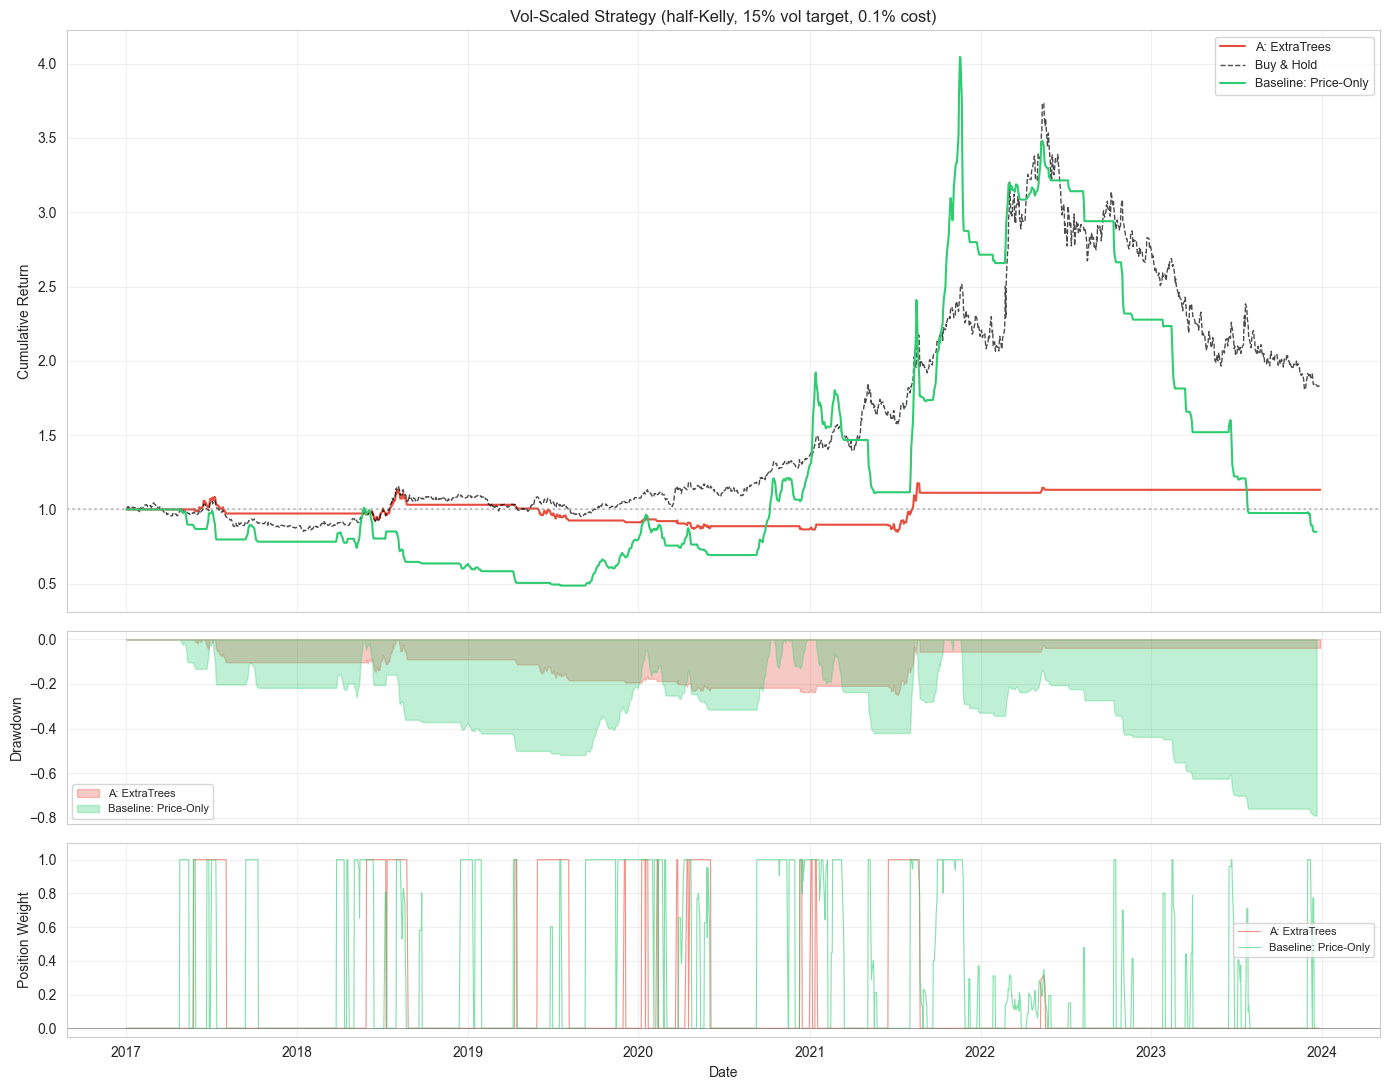

In [57]:
# %% [markdown]
# ---
# ## 7c. Trading Strategy Backtest (Regression Version)
#
# The regression-based strategy exploits three advantages of
# having a continuous predicted return rather than a binary
# direction:
#
# 1. **Volatility scaling** (Moskowitz, Ooi & Pedersen, 2012):
#    Position size is inversely proportional to recent realised
#    volatility. When markets are calm, the strategy sizes up;
#    when markets are volatile, it sizes down.
#
# 2. **Half-Kelly sizing** (Kelly, 1956; Thorp, 2006):
#    The predicted return magnitude determines position weight
#    via the continuous Kelly fraction f* = μ/σ², scaled to
#    half-Kelly for conservatism.
#
# 3. **Adaptive dead-zone** (Lecture 2: bias-variance):
#    The strategy only acts when the predicted return exceeds
#    the model's own recent prediction error - its noise floor.

# %%
# ============================================================
# Trading Strategy - Volatility-Scaled Regression Long/Flat
# ============================================================

TRADE_COST = 0.001
TARGET_VOL = 0.15
VOL_LOOKBACK = 20
KELLY_FRACTION = 0.75
MAX_WEIGHT = 1.0
DEAD_ZONE_FRAC = 0.05

# Pick top 2 models from leaderboard
top2_names = lb_df.index[:2].tolist()
print(f'Top 2 models for backtesting: {top2_names}\n')


def backtest_volscaled(predictions_df, futures_df, trade_cost=0.001,
                       target_vol=0.15, vol_lookback=20,
                       kelly_frac=0.25, max_weight=1.0,
                       dead_zone_frac=0.05,
                       lookback=40, min_hold=3, horizon=5):
    df = predictions_df.merge(
        futures_df[['Date', 'Price']],
        on='Date', how='left'
    ).dropna(subset=['Fwd_Return']).copy().reset_index(drop=True)

    df['rolling_vol'] = df['Fwd_Return'].rolling(vol_lookback, min_periods=10).std() * np.sqrt(252)
    df['rolling_var'] = df['Fwd_Return'].rolling(vol_lookback * 3, min_periods=20).var()

    weights = []
    regimes = []
    dead_zones = []
    past_predictions = []

    for idx in range(len(df)):
        pred_ret = df.loc[idx, 'y_pred']
        actual_return = df.loc[idx, 'Fwd_Return']
        r_vol = df.loc[idx, 'rolling_vol']
        r_var = df.loc[idx, 'rolling_var']

        past_predictions.append((idx, pred_ret, actual_return))

        settled = [(p, a) for (t, p, a) in past_predictions if t <= idx - horizon]
        recent = settled[-lookback:] if len(settled) >= lookback else settled

        if len(recent) >= 10:
            noise_est = np.mean([abs(p - a) for p, a in recent])
            recent_dir_acc = np.mean([1 if (p > 0) == (a > 0) else 0 for p, a in recent])
        else:
            noise_est = 0.01
            recent_dir_acc = 0.50

        dead_zones.append(noise_est)

        if recent_dir_acc >= 0.54:
            regime = 'HOT'
        elif recent_dir_acc <= 0.48:
            regime = 'COLD'
        else:
            regime = 'NEUTRAL'
        regimes.append(regime)

        if pred_ret <= noise_est * dead_zone_frac or np.isnan(r_vol) or r_vol <= 0 or np.isnan(r_var) or r_var <= 0:
            weights.append(0.0)
            continue

        if regime == 'COLD' and (len(weights) == 0 or weights[-1] == 0):
            weights.append(0.0)
            continue

        kelly_weight = kelly_frac * pred_ret / r_var
        vol_scalar = target_vol / r_vol
        raw_weight = kelly_weight * vol_scalar
        final_weight = np.clip(raw_weight, 0.0, max_weight)
        weights.append(final_weight)

    df['weight'] = weights
    df['regime'] = regimes
    df['dead_zone'] = dead_zones

    smoothed = df['weight'].copy()
    hold_counter = 0
    last_nonzero_weight = 0.0
    for idx in range(len(smoothed)):
        if hold_counter > 0:
            smoothed.iloc[idx] = last_nonzero_weight
            hold_counter -= 1
        elif smoothed.iloc[idx] > 0 and (idx == 0 or df['weight'].iloc[idx - 1] == 0):
            last_nonzero_weight = smoothed.iloc[idx]
            hold_counter = min_hold - 1
    df['weight'] = smoothed

    df['position'] = (df['weight'] > 0).astype(float)
    df['strategy_return_gross'] = df['weight'] * df['Fwd_Return']
    df['weight_change'] = df['weight'].diff().abs().fillna(df['weight'].abs())
    df['trade_costs'] = df['weight_change'] * trade_cost
    df['strategy_return'] = df['strategy_return_gross'] - df['trade_costs']
    df['bnh_return'] = df['Fwd_Return']
    df['cum_strategy'] = (1 + df['strategy_return']).cumprod()
    df['cum_bnh'] = (1 + df['bnh_return']).cumprod()

    total_ret = df['cum_strategy'].iloc[-1] - 1
    bnh_ret = df['cum_bnh'].iloc[-1] - 1
    n_trades = ((df['weight'] > 0) & (df['weight'].shift(1).fillna(0) == 0)).sum()
    total_costs = df['trade_costs'].sum()
    n_active = (df['weight'] > 0).sum()
    pct_active = n_active / len(df)
    daily_std = df['strategy_return'].std()
    sharpe = (df['strategy_return'].mean() / daily_std * np.sqrt(252)) if daily_std > 0 else 0
    cum = df['cum_strategy']
    max_dd = ((cum - cum.cummax()) / cum.cummax()).min()
    long_rets = df.loc[df['weight'] > 0, 'strategy_return']
    win_rate = (long_rets > 0).mean() if len(long_rets) > 0 else 0
    flat_days = df[df['weight'] == 0]
    avoided_loss = flat_days['Fwd_Return'].clip(upper=0).sum()
    avg_weight = df.loc[df['weight'] > 0, 'weight'].mean() if n_active > 0 else 0
    realised_vol = df['strategy_return'].std() * np.sqrt(252)
    regime_counts = df['regime'].value_counts()

    return {
        'df': df, 'total_return': total_ret, 'bnh_return': bnh_ret,
        'sharpe': sharpe, 'max_drawdown': max_dd, 'n_trades': n_trades,
        'total_costs': total_costs, 'win_rate': win_rate,
        'pct_active': pct_active, 'regime_counts': regime_counts,
        'avoided_loss': avoided_loss,
        'avg_weight': avg_weight, 'realised_vol': realised_vol,
    }


# ============================================================
# Universal prediction lookup
#
# Instead of brittle if/elif chains that break when model names
# change, we build a single dict mapping every model name to its
# predictions DataFrame. Then any name from the leaderboard
# resolves correctly.
# ============================================================

all_predictions = {}

# Approach A: per-region models (may have several variants)
for name, res in approach_a_results.items():
    all_predictions[name] = res['predictions']

# Approach B
if 'approach_b_result' in dir() and approach_b_result:
    all_predictions['B: Lasso Stack'] = approach_b_result['predictions']

# Approach C
if 'approach_c_result' in dir() and approach_c_result:
    all_predictions['C: PCA + Lasso'] = approach_c_result['predictions']

# Approach D
if 'approach_d_result' in dir() and approach_d_result:
    all_predictions['D: PCA + ExtraTrees'] = approach_d_result['predictions']

# Approach E
if 'approach_e_result' in dir() and approach_e_result:
    all_predictions['E: Wide ExtraTrees'] = approach_e_result['predictions']

# Baseline
if 'baseline_result' in dir() and baseline_result:
    all_predictions['Baseline: Price-Only'] = baseline_result['predictions']

print(f"Available models for backtesting: {list(all_predictions.keys())}")

# ---- Run for top 2 models ----
backtest_results = {}
for name in top2_names:
    if name not in all_predictions:
        print(f"  {name}: predictions not found, skipping")
        print(f"    Available: {list(all_predictions.keys())}")
        continue

    preds = all_predictions[name]

    bt = backtest_volscaled(preds, futures, trade_cost=TRADE_COST,
                            target_vol=TARGET_VOL,
                            vol_lookback=VOL_LOOKBACK,
                            kelly_frac=KELLY_FRACTION,
                            max_weight=MAX_WEIGHT,
                            dead_zone_frac=DEAD_ZONE_FRAC,
                            horizon=FORECAST_HORIZON)
    backtest_results[name] = bt
    excess = bt['total_return'] - bt['bnh_return']
    print(f"{name}:")
    print(f"  Return: {bt['total_return']:+.2%}  |  B&H: {bt['bnh_return']:+.2%}  |  "
          f"Excess: {excess:+.2%}")
    print(f"  Sharpe: {bt['sharpe']:.2f}  |  MaxDD: {bt['max_drawdown']:.2%}  |  "
          f"Win: {bt['win_rate']:.1%}")
    print(f"  Long: {bt['pct_active']:.0%} of days  |  Flat: {1-bt['pct_active']:.0%} of days")
    print(f"  Avg weight when long: {bt['avg_weight']:.2f}  |  "
          f"Realised vol: {bt['realised_vol']:.1%}")
    print(f"  Trades: {bt['n_trades']}  |  Costs: {bt['total_costs']:.4f}")
    print(f"  Regime: {dict(bt['regime_counts'])}")
    print()

if not backtest_results:
    print("WARNING: No models were backtested. Check that model names in "
          "the leaderboard match the approach result variables above.")

# ---- Equity curves ----
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1, 1]})

ax = axes[0]
colors_bt = ['#e74c3c', '#2ecc71']
bnh_plotted = False
for j, name in enumerate(backtest_results.keys()):
    bt = backtest_results[name]
    df_bt = bt['df']
    ax.plot(df_bt['Date'], df_bt['cum_strategy'], label=name,
            color=colors_bt[j % len(colors_bt)], linewidth=1.5)
    if not bnh_plotted:
        ax.plot(df_bt['Date'], df_bt['cum_bnh'], label='Buy & Hold',
                color='black', linewidth=1, linestyle='--', alpha=0.7)
        bnh_plotted = True
ax.axhline(1.0, color='grey', linestyle=':', alpha=0.5)
ax.set_ylabel('Cumulative Return')
ax.set_title(f'Vol-Scaled Strategy (half-Kelly, {TARGET_VOL:.0%} vol target, '
             f'{TRADE_COST*100}% cost)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
for j, name in enumerate(backtest_results.keys()):
    bt = backtest_results[name]
    df_bt = bt['df']
    cum = df_bt['cum_strategy']
    dd = (cum - cum.cummax()) / cum.cummax()
    ax2.fill_between(df_bt['Date'], dd, 0, alpha=0.3,
                     color=colors_bt[j % len(colors_bt)], label=name)
ax2.set_ylabel('Drawdown')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

ax3 = axes[2]
for j, name in enumerate(backtest_results.keys()):
    bt = backtest_results[name]
    df_bt = bt['df']
    ax3.plot(df_bt['Date'], df_bt['weight'],
             color=colors_bt[j % len(colors_bt)], alpha=0.6, linewidth=0.8, label=name)
ax3.set_ylabel('Position Weight')
ax3.set_xlabel('Date')
ax3.set_ylim(-0.05, MAX_WEIGHT + 0.1)
ax3.axhline(0, color='grey', linewidth=0.5)
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Top 2 models for regime sampling: ['A: ExtraTrees', 'Baseline: Price-Only']

Test period: 2017-01-02 to 2023-12-28
Generated 40 overlapping 0.5-year windows (step = 2 months)

  A: ExtraTrees: 40 windows evaluated
  Baseline: Price-Only: 40 windows evaluated

REGIME-SAMPLING RESULTS (Vol-Scaled Regression Strategy)

────────────────────────────────────────────────────────────────────────────────
  A: ExtraTrees
────────────────────────────────────────────────────────────────────────────────
  Windows: 40
  Strategy beats B&H: 15/40 (38%)
  Median excess return:  -6.12%
  Mean excess return:    -5.97%
  Mean Sharpe:           -0.04
  Worst max drawdown:    -10.99%
  Mean win rate:         30.4%
  Mean % time long:      15%
  Mean avg weight:       0.67
  Mean strategy vol:     5.7%
  Mean B&H vol:          20.7%
  Mean vol reduction:    73%

  Per-regime breakdown:
    Bear / High-Vol       n= 1  med_excess=+19.01%  beats_bnh=100%  sharpe=0.00
    Bear / Low-Vol        n= 3  med_excess=

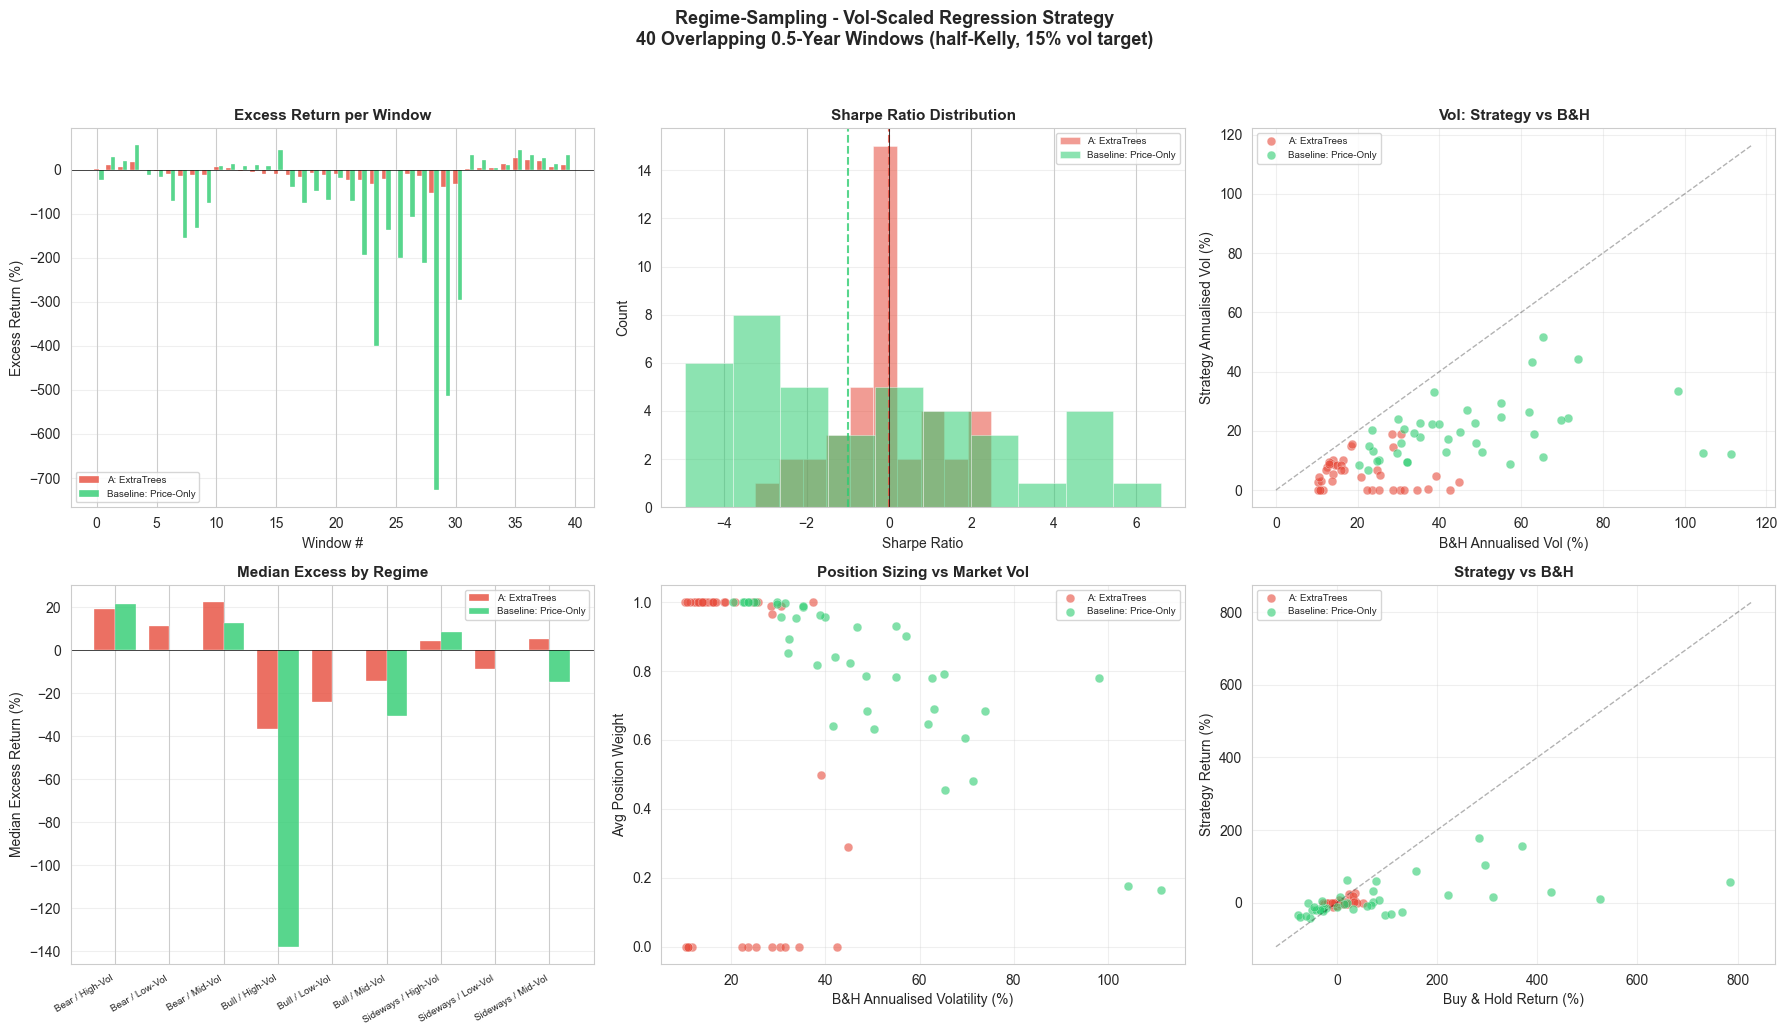

In [58]:
# ============================================================
# Regime-Sampling Backtest (Volatility-Scaled Regression)
# ============================================================

from datetime import timedelta
from collections import defaultdict

WINDOW_YEARS = 0.5
STEP_MONTHS = 2
MIN_DAYS = 100

top2_names = lb_df.index[:2].tolist()
print(f"Top 2 models for regime sampling: {top2_names}\n")

# Helper to get predictions for any model name
def get_predictions(name):
    if name in approach_a_results:
        return approach_a_results[name]['predictions']
    elif name == 'B: Lasso Stack' and approach_b_result:
        return approach_b_result['predictions']
    elif name == 'C: PCA + Ridge' and approach_c_result:
        return approach_c_result['predictions']
    elif name == 'Baseline: Price-Only' and baseline_result:
        return baseline_result['predictions']
    return None

# Generate windows
sample_preds = get_predictions(top2_names[0])
test_date_min = sample_preds['Date'].min()
test_date_max = sample_preds['Date'].max()

windows = []
win_start = test_date_min
while win_start + timedelta(days=WINDOW_YEARS * 365) <= test_date_max + timedelta(days=30):
    win_end = win_start + timedelta(days=WINDOW_YEARS * 365)
    windows.append((win_start, min(win_end, test_date_max)))
    win_start += pd.DateOffset(months=STEP_MONTHS)

print(f"Test period: {test_date_min.date()} to {test_date_max.date()}")
print(f"Generated {len(windows)} overlapping {WINDOW_YEARS}-year windows "
      f"(step = {STEP_MONTHS} months)\n")

# Run vol-scaled backtest on each window
regime_results = defaultdict(list)

for model_name in top2_names:
    preds_full = get_predictions(model_name)
    if preds_full is None:
        print(f"  {model_name}: no predictions found, skipping")
        continue

    preds_full = preds_full.copy()

    for i, (ws, we) in enumerate(windows):
        mask = (preds_full['Date'] >= ws) & (preds_full['Date'] <= we)
        preds_window = preds_full[mask].reset_index(drop=True)

        if len(preds_window) < MIN_DAYS:
            continue

        bt = backtest_volscaled(
            preds_window, futures,
            trade_cost=TRADE_COST,
            target_vol=TARGET_VOL,
            vol_lookback=VOL_LOOKBACK,
            kelly_frac=KELLY_FRACTION,
            max_weight=MAX_WEIGHT,
            dead_zone_frac=DEAD_ZONE_FRAC,
            horizon=FORECAST_HORIZON
        )

        bnh_daily_std = bt['df']['Fwd_Return'].std()
        bnh_ann_vol = bnh_daily_std * np.sqrt(252)
        bnh_total = bt['bnh_return']

        if bnh_ann_vol > 0.30:
            vol_label = 'High-Vol'
        elif bnh_ann_vol < 0.18:
            vol_label = 'Low-Vol'
        else:
            vol_label = 'Mid-Vol'

        if bnh_total > 0.15:
            trend_label = 'Bull'
        elif bnh_total < -0.10:
            trend_label = 'Bear'
        else:
            trend_label = 'Sideways'

        regime_results[model_name].append({
            'window': f"{ws.date()} → {we.date()}",
            'start': ws, 'end': we,
            'n_days': len(bt['df']),
            'strategy_ret': bt['total_return'],
            'bnh_ret': bt['bnh_return'],
            'excess': bt['total_return'] - bt['bnh_return'],
            'sharpe': bt['sharpe'],
            'max_dd': bt['max_drawdown'],
            'win_rate': bt['win_rate'],
            'pct_long': bt['pct_active'],
            'avg_weight': bt['avg_weight'],
            'n_trades': bt['n_trades'],
            'strat_ann_vol': bt['realised_vol'],
            'bnh_ann_vol': bnh_ann_vol,
            'regime': f"{trend_label} / {vol_label}",
        })

    print(f"  {model_name}: {len(regime_results[model_name])} windows evaluated")

# Summary
summary_dfs = {}
for model_name in top2_names:
    if model_name not in regime_results:
        continue
    df = pd.DataFrame(regime_results[model_name])
    df = df.sort_values('start').reset_index(drop=True)
    # df = df[df['excess'].abs() <= 10].reset_index(drop=True)
    summary_dfs[model_name] = df

print("\n" + "="*80)
print("REGIME-SAMPLING RESULTS (Vol-Scaled Regression Strategy)")
print("="*80)

for model_name in summary_dfs:
    df = summary_dfs[model_name]
    print(f"\n{'─'*80}")
    print(f"  {model_name}")
    print(f"{'─'*80}")
    print(f"  Windows: {len(df)}")
    print(f"  Strategy beats B&H: {(df['excess'] > 0).sum()}/{len(df)} "
          f"({(df['excess'] > 0).mean():.0%})")
    print(f"  Median excess return:  {df['excess'].median():+.2%}")
    print(f"  Mean excess return:    {df['excess'].mean():+.2%}")
    print(f"  Mean Sharpe:           {df['sharpe'].mean():.2f}")
    print(f"  Worst max drawdown:    {df['max_dd'].min():.2%}")
    print(f"  Mean win rate:         {df['win_rate'].mean():.1%}")
    print(f"  Mean % time long:      {df['pct_long'].mean():.0%}")
    print(f"  Mean avg weight:       {df['avg_weight'].mean():.2f}")
    print(f"  Mean strategy vol:     {df['strat_ann_vol'].mean():.1%}")
    print(f"  Mean B&H vol:          {df['bnh_ann_vol'].mean():.1%}")
    if df['bnh_ann_vol'].mean() > 0:
        print(f"  Mean vol reduction:    "
              f"{(1 - df['strat_ann_vol'].mean() / df['bnh_ann_vol'].mean()):.0%}")

    print(f"\n  Per-regime breakdown:")
    for regime in sorted(df['regime'].unique()):
        sub = df[df['regime'] == regime]
        print(f"    {regime:20s}  n={len(sub):2d}  "
              f"med_excess={sub['excess'].median():+.2%}  "
              f"beats_bnh={sub['excess'].gt(0).mean():.0%}  "
              f"sharpe={sub['sharpe'].mean():.2f}")

# Full window table
for model_name in summary_dfs:
    df = summary_dfs[model_name]
    print(f"\n{'='*80}")
    print(f"  {model_name} - All Windows")
    print(f"{'='*80}")
    display_cols = ['window', 'regime', 'strategy_ret', 'bnh_ret',
                    'excess', 'sharpe', 'max_dd', 'win_rate',
                    'pct_long', 'avg_weight', 'strat_ann_vol', 'bnh_ann_vol']
    print(df[display_cols].to_string(
        index=False,
        formatters={
            'strategy_ret':  '{:+.2%}'.format,
            'bnh_ret':       '{:+.2%}'.format,
            'excess':        '{:+.2%}'.format,
            'sharpe':        '{:.2f}'.format,
            'max_dd':        '{:.2%}'.format,
            'win_rate':      '{:.1%}'.format,
            'pct_long':      '{:.0%}'.format,
            'avg_weight':    '{:.2f}'.format,
            'strat_ann_vol': '{:.1%}'.format,
            'bnh_ann_vol':   '{:.1%}'.format,
        }
    ))

# Visualisation
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
model_colors = {}
color_list = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
for j, name in enumerate(summary_dfs.keys()):
    model_colors[name] = color_list[j % len(color_list)]

ax = axes[0, 0]
bar_w = 0.38
for j, name in enumerate(summary_dfs.keys()):
    df = summary_dfs[name]
    vals = df['excess'].values
    ax.bar(np.arange(len(vals)) + j * bar_w, vals * 100, bar_w,
           label=name, color=model_colors[name], alpha=0.8,
           edgecolor='white', linewidth=0.3)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Excess Return (%)')
ax.set_title('Excess Return per Window', fontsize=11, fontweight='bold')
ax.set_xlabel('Window #')
ax.legend(fontsize=7)
ax.grid(axis='y', alpha=0.3)

ax = axes[0, 1]
for name in summary_dfs:
    df = summary_dfs[name]
    ax.hist(df['sharpe'], bins=10, alpha=0.55, label=name,
            color=model_colors[name], edgecolor='white', linewidth=0.5)
    ax.axvline(df['sharpe'].median(), color=model_colors[name],
               linestyle='--', linewidth=1.5, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Sharpe Ratio')
ax.set_ylabel('Count')
ax.set_title('Sharpe Ratio Distribution', fontsize=11, fontweight='bold')
ax.legend(fontsize=7)
ax.grid(axis='y', alpha=0.3)

ax = axes[0, 2]
for name in summary_dfs:
    df = summary_dfs[name]
    ax.scatter(df['bnh_ann_vol'] * 100, df['strat_ann_vol'] * 100,
               alpha=0.6, s=40, color=model_colors[name], label=name,
               edgecolors='white', linewidth=0.3)
lims = [0, max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', alpha=0.3, linewidth=1)
ax.set_xlabel('B&H Annualised Vol (%)')
ax.set_ylabel('Strategy Annualised Vol (%)')
ax.set_title('Vol: Strategy vs B&H', fontsize=11, fontweight='bold')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

ax = axes[1, 0]
all_regimes = sorted(set(
    r for name in summary_dfs for r in summary_dfs[name]['regime'].unique()
))
x_reg = np.arange(len(all_regimes))
for j, name in enumerate(summary_dfs.keys()):
    df = summary_dfs[name]
    medians = [df[df['regime'] == r]['excess'].median() if r in df['regime'].values else 0
               for r in all_regimes]
    ax.bar(x_reg + j * bar_w, [m * 100 for m in medians], bar_w,
           label=name, color=model_colors[name], alpha=0.8,
           edgecolor='white', linewidth=0.3)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x_reg + bar_w / 2)
ax.set_xticklabels(all_regimes, fontsize=7, rotation=30, ha='right')
ax.set_ylabel('Median Excess Return (%)')
ax.set_title('Median Excess by Regime', fontsize=11, fontweight='bold')
ax.legend(fontsize=7)
ax.grid(axis='y', alpha=0.3)

ax = axes[1, 1]
for name in summary_dfs:
    df = summary_dfs[name]
    ax.scatter(df['bnh_ann_vol'] * 100, df['avg_weight'],
               alpha=0.6, s=40, color=model_colors[name], label=name,
               edgecolors='white', linewidth=0.3)
ax.set_xlabel('B&H Annualised Volatility (%)')
ax.set_ylabel('Avg Position Weight')
ax.set_title('Position Sizing vs Market Vol', fontsize=11, fontweight='bold')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

ax = axes[1, 2]
for name in summary_dfs:
    df = summary_dfs[name]
    ax.scatter(df['bnh_ret'] * 100, df['strategy_ret'] * 100,
               alpha=0.6, s=40, color=model_colors[name], label=name,
               edgecolors='white', linewidth=0.3)
lims = ax.get_xlim()
ax.plot(lims, lims, 'k--', alpha=0.3, linewidth=1)
ax.set_xlabel('Buy & Hold Return (%)')
ax.set_ylabel('Strategy Return (%)')
ax.set_title('Strategy vs B&H', fontsize=11, fontweight='bold')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

fig.suptitle(f'Regime-Sampling - Vol-Scaled Regression Strategy\n'
             f'{len(windows)} Overlapping {WINDOW_YEARS}-Year Windows '
             f'(half-Kelly, {TARGET_VOL:.0%} vol target)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()